#### Reto: "Predicción de Fallos en Equipos en Plantas Energéticas a 15 días vista"

Objetivo del Reto:

Evolucionar la solución para desarrollar un modelo analítico predictivo que permita anticipar fallos a 15 días vista en los equipos de la planta energética con una ***precisión mínima del 80% (accuracy ≥ 0.80) y por lo menos un 0.75 de f1.***

Por un lado se quiere predecir las horas operativas que tendrá un equipo en los próximos 15 días, de cara a considerar su mantenimiento conforme a las horas recomendadas de revisión.

Por otro lado, se quiere evaluar si una máquina fallará en los próximos 15 días, con un 80% de fiabilidad.

Evalúa la robustés del modelo en el tiempo.

Para lograr esto, deberéis:

Mezclar y preprocesar los datos de los 3 datasets proporcionados, teniendo en cuenta la componente temporal.

Seleccionar variables relevantes y generar nuevas características si es necesario. Considera usar PCA para reducir dimensiones (conservando 95% de la varianza).

Construir y evaluar múltiples modelos predictivos, que inclyan forecasting y comparando su rendimiento.

Ajustar hiperparámetros y optimizar el modelo para alcanzar la precisión deseada.

Documentar los hallazgos y justificar la elección del mejor modelo.

Bonus 1: Encontrar patrones de fallos

Usa K-Means o DBSCAN para agrupar los equipos según sus condiciones operativas y comportamiento previo a los fallos.

Incluye las siguientes características para el clustering:

Promedio de temperatura y vibración por equipo.

Desviación estándar de temperatura y vibración.

Horas operativas acumuladas promedio.

Visualiza los clusters utilizando gráficos de dispersión o mapas de calor.

Interpreta los resultados: ¿Qué patrones emergen? ¿Hay grupos de equipos más propensos a fallar?


In [65]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import io
import sys
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

from typing import Tuple
from sklearn.base import RegressorMixin
from typing import Tuple, List
from sklearn.pipeline import Pipeline
from sklearn.base import RegressorMixin
from typing import Optional
from sklearn.base import ClassifierMixin

from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from typing import Tuple, List, Dict
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score

from sklearn.pipeline import make_pipeline

In [21]:
# Cargar el CSV
ruta_csv = "../src/Datos_agregados.csv"
df = pd.read_csv(ruta_csv)

# Mostrar las primeras filas y la info general
primeras_filas = df.head()
info_general = df.info()
resumen_estadistico = df.describe()

primeras_filas, resumen_estadistico


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4068 entries, 0 to 4067
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID_Equipo                    4068 non-null   int64  
 1   Tipo_Equipo                  4068 non-null   int64  
 2   Fabricante                   4068 non-null   int64  
 3   Modelo                       4068 non-null   int64  
 4   Potencia_kW                  4068 non-null   float64
 5   Horas_Recomendadas_Revision  4068 non-null   float64
 6   Tipo_Mantenimiento           4068 non-null   int64  
 7   Quincena                     4068 non-null   int64  
 8   Costo_Mantenimiento          4068 non-null   float64
 9   Temperatura_C                4068 non-null   float64
 10  Vibracion_mm_s               4068 non-null   float64
 11  Horas_Operativas             4068 non-null   float64
 12  horas_hasta_correctivo       4068 non-null   float64
dtypes: float64(7), int

(   ID_Equipo  Tipo_Equipo  Fabricante  Modelo  Potencia_kW  \
 0          1            0           0       8        432.0   
 1          1            0           0       8        432.0   
 2          1            0           0       8        432.0   
 3          1            0           0       8        432.0   
 4          1            0           0       8        432.0   
 
    Horas_Recomendadas_Revision  Tipo_Mantenimiento  Quincena  \
 0                        657.0                   0         1   
 1                        657.0                   0         2   
 2                        657.0                   0         3   
 3                        657.0                   1         1   
 4                        657.0                   1         2   
 
    Costo_Mantenimiento  Temperatura_C  Vibracion_mm_s  Horas_Operativas  \
 0              94391.0      94.264232        9.862454        160.821429   
 1             239363.0      97.823893        9.931615         77.141176   


### 🔹 **Paso 1: Carga y exploración rápida de `Datos_agregados.csv`**

Voy a mostrarte:

- Las primeras filas del dataset.
- Información general (columnas, tipos de datos, nulos).
- Un pequeño resumen estadístico para entender las variables.

Procedo a hacerlo:

Listo, aquí tienes un resumen del dataset `Datos_agregados.csv`:

---

### 📊 **Columnas del dataset**
| Columna                     | Descripción                                        |
|----------------------------|----------------------------------------------------|
| `ID_Equipo`                | Identificador único del equipo                     |
| `Tipo_Equipo`, `Fabricante`, `Modelo` | Variables categóricas codificadas numéricamente |
| `Potencia_kW`              | Potencia del equipo en kW                         |
| `Horas_Recomendadas_Revision` | Umbral de horas antes de requerir revisión        |
| `Tipo_Mantenimiento`       | 0: Preventivo, 1: Correctivo                       |
| `Quincena`                 | 1, 2 o 3 (posiblemente el período del mes)         |
| `Costo_Mantenimiento`      | Coste asociado a ese mantenimiento                 |
| `Temperatura_C`            | Promedio temperatura quincenal del equipo          |
| `Vibracion_mm_s`           | Promedio vibración quincenal del equipo            |
| `Horas_Operativas`         | Horas operadas en esa quincena                    |
| `horas_hasta_correctivo`   | Horas restantes hasta un fallo correctivo.         |

---

### 📌 Observaciones clave
- Hay **4068 registros**.
- No hay valores nulos.
- La variable `horas_hasta_correctivo` tiene valores **negativos**, lo cual sugiere que algunos mantenimientos correctivos **ya ocurrieron**.
- `Tipo_Mantenimiento` puede servir como **etiqueta para clasificación** (si el mantenimiento fue correctivo = 1).

---

### ✅ Siguiente paso sugerido: **Ingeniería de características**

Te propongo ahora generar estas nuevas columnas:
1. `fallo_15_dias` → **binaria**, 1 si `horas_hasta_correctivo` ≤ 360 (15 días * 24 horas).
2. Comprobar si hace falta normalizar o transformar otras variables para los modelos.


In [22]:
# Crear columna binaria: 1 si el equipo fallará en 15 días (360 horas), 0 si no
df["fallo_15_dias"] = df["horas_hasta_correctivo"].apply(lambda x: 1 if x <= 360 else 0)

# Ver distribución de clases
distribucion_fallos = df["fallo_15_dias"].value_counts().to_frame(name="conteo")
distribucion_fallos["porcentaje"] = round(100 * distribucion_fallos["conteo"] / df.shape[0], 2)

distribucion_fallos


,conteo,porcentaje
fallo_15_dias,,
1,2302,56.59
0,1766,43.41


#### *Sobre la tabla con la distribución de clases (fallo_15_dias), podemos obtener las siguientes gráficas:*

1. Gráfico de barras para mostrar el conteo de cada clase.

2. Gráfico de pastel (pie chart) para mostrar el porcentaje.



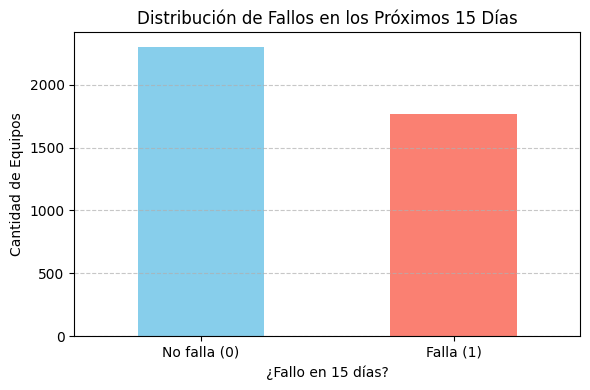

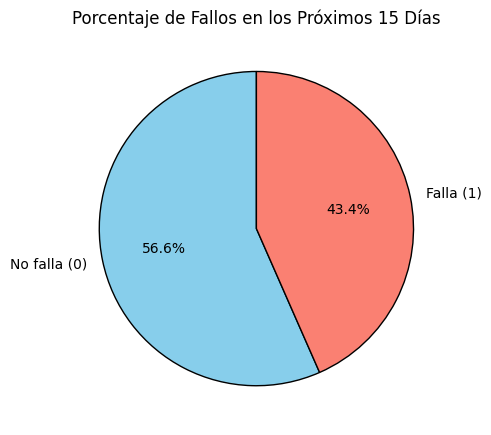

In [23]:
# Gráfico de barras
plt.figure(figsize=(6, 4))
distribucion_fallos["conteo"].plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Distribución de Fallos en los Próximos 15 Días")
plt.xlabel("¿Fallo en 15 días?")
plt.ylabel("Cantidad de Equipos")
plt.xticks([0, 1], labels=["No falla (0)", "Falla (1)"], rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Gráfico de pastel
plt.figure(figsize=(5, 5))
plt.pie(distribucion_fallos["porcentaje"], 
        labels=["No falla (0)", "Falla (1)"],
        autopct="%1.1f%%", 
        colors=["skyblue", "salmon"],
        startangle=90,
        wedgeprops={'edgecolor': 'black'})
plt.title("Porcentaje de Fallos en los Próximos 15 Días")
plt.tight_layout()
plt.show()


In [24]:
# Mostrar el dataframe con display
display(df.head(10))

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,Tipo_Mantenimiento,Quincena,Costo_Mantenimiento,Temperatura_C,Vibracion_mm_s,Horas_Operativas,horas_hasta_correctivo,fallo_15_dias
0,1,0,0,8,432.0,657.0,0,1,94391.0,94.264232,9.862454,160.821429,496.178571,0
1,1,0,0,8,432.0,657.0,0,2,239363.0,97.823893,9.931615,77.141176,579.858824,0
2,1,0,0,8,432.0,657.0,0,3,10184.0,89.525381,6.229608,150.250000,506.750000,0
3,1,0,0,8,432.0,657.0,1,1,341679.0,99.998314,9.982758,1303.188791,-646.188791,1
4,1,0,0,8,432.0,657.0,1,2,309888.0,99.825028,9.976351,1414.309446,-757.309446,1
5,1,0,0,8,432.0,657.0,1,3,12526.0,93.560856,9.720170,1425.375000,-768.375000,1
6,2,0,0,8,432.0,657.0,1,1,13050.0,94.594572,9.795655,796.200000,-139.200000,1
7,2,0,0,8,432.0,657.0,1,2,5220.0,90.502808,8.535190,915.000000,-258.000000,1
8,2,2,1,2,393.0,522.0,0,1,163670.0,97.967097,9.976694,73.639344,448.360656,0
9,2,2,1,2,393.0,522.0,0,2,205898.0,96.666022,9.969722,97.614286,424.385714,0


### 🔹 **Paso 2: Forecasting de Horas Operativas**

#### 🎯 Objetivo:
Predecir las `Horas_Operativas` que tendrá un equipo en los próximos 15 días (quincena siguiente), para planificar mantenimientos con base en su límite de revisión.

---

### 🔧 Estrategia propuesta:

1. **Convertir datos a formato serie temporal por equipo y quincena.**
2. Entrenar un modelo de regresión para predecir `Horas_Operativas` en t+1.
   - Opción simple: usar `RandomForestRegressor` o `XGBoostRegressor`.
   - Alternativa: modelos de series temporales (ARIMA, Prophet, etc.).
3. Evaluar precisión del modelo (RMSE, MAE, R²).
4. Verificar que la predicción se acerque al objetivo de planificación.

In [25]:
# Ordenar por equipo y quincena
df_sorted = df.sort_values(by=["ID_Equipo", "Quincena"]).copy()

# Crear la variable target: Horas_Operativas de la siguiente quincena
df_sorted["Horas_Operativas_t+1"] = df_sorted.groupby("ID_Equipo")["Horas_Operativas"].shift(-1)

# Eliminar filas con NaN en el target (última quincena por equipo)
df_modelo_reg = df_sorted.dropna(subset=["Horas_Operativas_t+1"]).copy()

# Variables predictoras (puedes ajustar esta selección si lo deseas)
columnas_X = [
    "ID_Equipo", "Tipo_Equipo", "Fabricante", "Modelo", "Potencia_kW",
    "Horas_Recomendadas_Revision", "Tipo_Mantenimiento", "Quincena",
    "Costo_Mantenimiento", "Temperatura_C", "Vibracion_mm_s", "Horas_Operativas"
]
X = df_modelo_reg[columnas_X]
y = df_modelo_reg["Horas_Operativas_t+1"]

X.head(), y.head()

(   ID_Equipo  Tipo_Equipo  Fabricante  Modelo  Potencia_kW  \
 0          1            0           0       8        432.0   
 3          1            0           0       8        432.0   
 1          1            0           0       8        432.0   
 4          1            0           0       8        432.0   
 2          1            0           0       8        432.0   
 
    Horas_Recomendadas_Revision  Tipo_Mantenimiento  Quincena  \
 0                        657.0                   0         1   
 3                        657.0                   1         1   
 1                        657.0                   0         2   
 4                        657.0                   1         2   
 2                        657.0                   0         3   
 
    Costo_Mantenimiento  Temperatura_C  Vibracion_mm_s  Horas_Operativas  
 0              94391.0      94.264232        9.862454        160.821429  
 3             341679.0      99.998314        9.982758       1303.188791  
 1 

#### *1. Distribución de la variable objetivo (Horas_Operativas_t+1)*

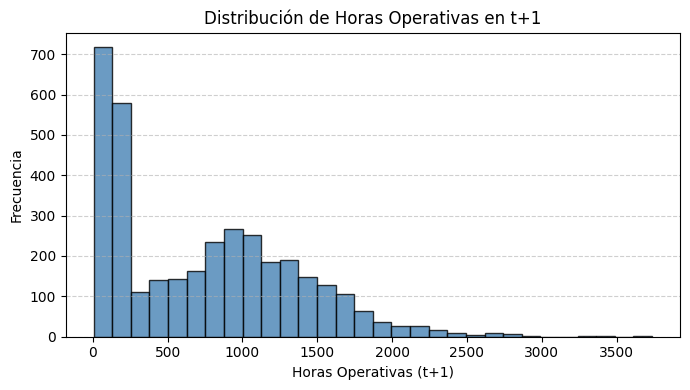

In [26]:
plt.figure(figsize=(7, 4))
plt.hist(y, bins=30, color="steelblue", edgecolor="black", alpha=0.8)
plt.title("Distribución de Horas Operativas en t+1")
plt.xlabel("Horas Operativas (t+1)")
plt.ylabel("Frecuencia")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

#### * 2. Promedio de Horas_Operativas_t+1 por tipo de equipo*

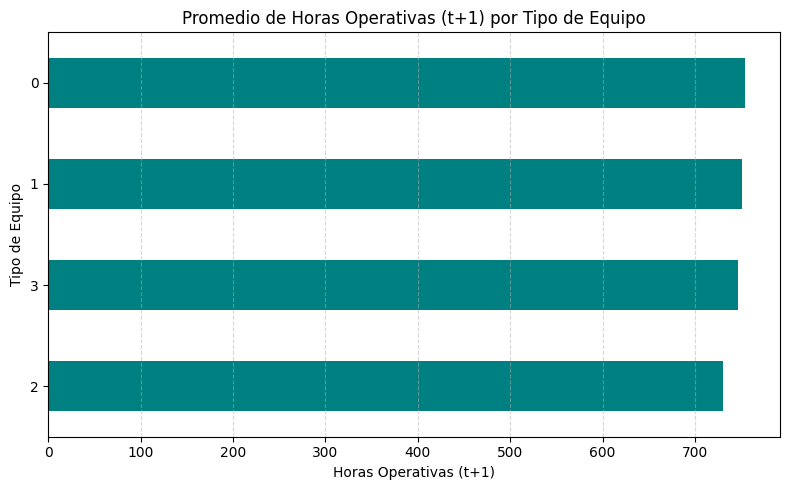

In [27]:
media_por_tipo = df_modelo_reg.groupby("Tipo_Equipo")["Horas_Operativas_t+1"].mean().sort_values()

plt.figure(figsize=(8, 5))
media_por_tipo.plot(kind="barh", color="teal")
plt.title("Promedio de Horas Operativas (t+1) por Tipo de Equipo")
plt.xlabel("Horas Operativas (t+1)")
plt.ylabel("Tipo de Equipo")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


#### *3. Relación entre variables clave y Horas_Operativas_t+1*

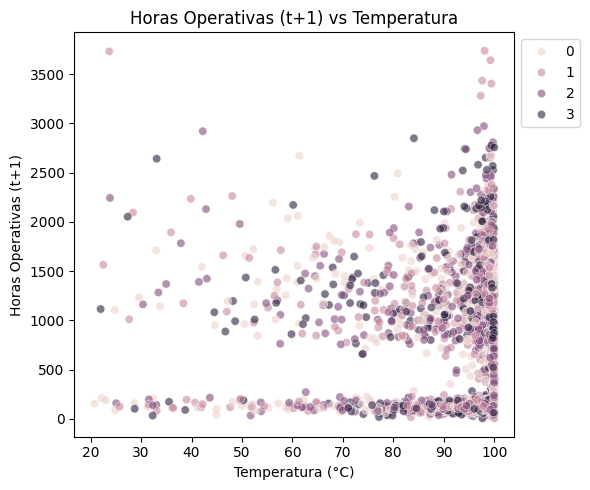

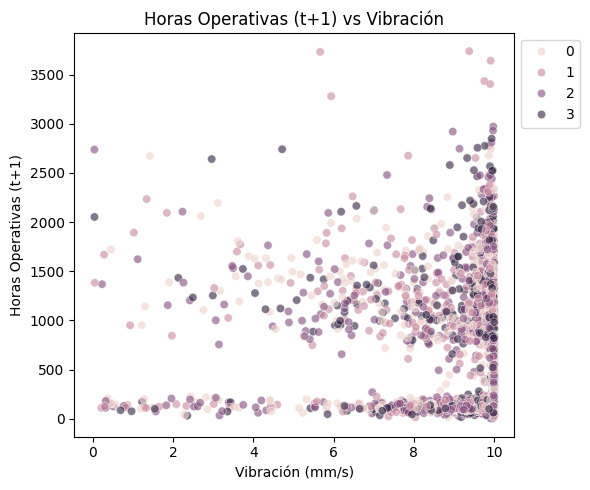

In [28]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_modelo_reg, x="Temperatura_C", y="Horas_Operativas_t+1", hue="Tipo_Equipo", alpha=0.6)
plt.title("Horas Operativas (t+1) vs Temperatura")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Horas Operativas (t+1)")
plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_modelo_reg, x="Vibracion_mm_s", y="Horas_Operativas_t+1", hue="Tipo_Equipo", alpha=0.6)
plt.title("Horas Operativas (t+1) vs Vibración")
plt.xlabel("Vibración (mm/s)")
plt.ylabel("Horas Operativas (t+1)")
plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


### 🔹 Paso 3: Preparación de datos para forecasting (modelo global)

#### 🛠 Qué haremos:
1. Reordenar los datos por `ID_Equipo` y `Quincena`.
2. Crear la variable **target**: `Horas_Operativas_t+1` (shift -1 por equipo).
3. Eliminar las filas donde no tengamos `target`.
4. Seleccionar variables predictoras (X) y la variable objetivo (y).

Procedo con eso ahora:

✅ Datos preparados para el modelo global de forecasting.

---

### 🎯 Objetivo:
Predecir la variable `Horas_Operativas_t+1` usando características técnicas y operativas de la quincena actual.

In [29]:
from typing import Tuple, List
from sklearn.pipeline import Pipeline
from sklearn.base import RegressorMixin

def entrenar_forecasting_modelo_global(
    df: pd.DataFrame,
    columnas_features: List[str],
    columna_target: str = "Horas_Operativas_t+1",
    modelo: RegressorMixin = None,
    test_size: float = 0.2,
    random_state: int = 42
) -> Tuple[Pipeline, float, float, float]:
    """
    Entrena un modelo global de forecasting sobre un dataframe con columnas ya construidas.
    
    Returns:
        pipeline (Pipeline): Pipeline entrenado (Scaler + Modelo).
        mae (float): Error absoluto medio.
        rmse (float): Raíz del error cuadrático medio.
        r2 (float): Coeficiente de determinación.
    """
    import numpy as np
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline
    from sklearn.ensemble import RandomForestRegressor

    if modelo is None:
        modelo = RandomForestRegressor(n_estimators=100, random_state=random_state)

    # Eliminar filas con NaNs en la columna target
    df_valid = df.dropna(subset=[columna_target]).copy()
    X = df_valid[columnas_features]
    y = df_valid[columna_target]

    # Split de datos
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Pipeline con escalado y modelo
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", modelo)
    ])

    # Entrenamiento
    pipeline.fit(X_train, y_train)

    # Evaluación
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return pipeline, mae, rmse, r2


#### *El código para llamar a la función con los datos que ya preparamos (df_modelo_reg) y las columnas correctas (columnas_X). Esto hará que entrene el modelo y nos dé las métricas:*

In [30]:
# Ejecutar la función de forecasting global
modelo_rf, mae_rf, rmse_rf, r2_rf = entrenar_forecasting_modelo_global(
    df=df_modelo_reg,
    columnas_features=columnas_X
)

# Mostrar resultados
print(f"MAE: {mae_rf:.2f} horas")
print(f"RMSE: {rmse_rf:.2f} horas")
print(f"R²: {r2_rf:.3f}")


MAE: 183.74 horas
RMSE: 270.75 horas
R²: 0.799


#### *Funciones para generar las gráficas:*

1. plot_ytrue_vs_ypred

2. plot_residual_histogram

3. plot_feature_importance

In [31]:
def plot_ytrue_vs_ypred(y_test, y_pred):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolor='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Valores Reales (y_test)")
    plt.ylabel("Predicciones (y_pred)")
    plt.title("Predicciones vs Valores Reales")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_residual_histogram(y_test, y_pred):
    residuals = y_test - y_pred
    plt.figure(figsize=(7, 4))
    plt.hist(residuals, bins=30, color="purple", alpha=0.7, edgecolor="black")
    plt.title("Distribución del Error Residual")
    plt.xlabel("Residual (y_test - y_pred)")
    plt.ylabel("Frecuencia")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_feature_importance(pipeline, feature_names):
    modelo = pipeline.named_steps["regressor"] if hasattr(pipeline, "named_steps") else pipeline
    if hasattr(modelo, "feature_importances_"):
        importances = modelo.feature_importances_
        feat_imp_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values(by="importance", ascending=False)

        plt.figure(figsize=(8, 5))
        plt.barh(feat_imp_df["feature"], feat_imp_df["importance"], color="slateblue")
        plt.title("Importancia de Características")
        plt.xlabel("Importancia")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("El modelo no tiene atributo `feature_importances_`.")


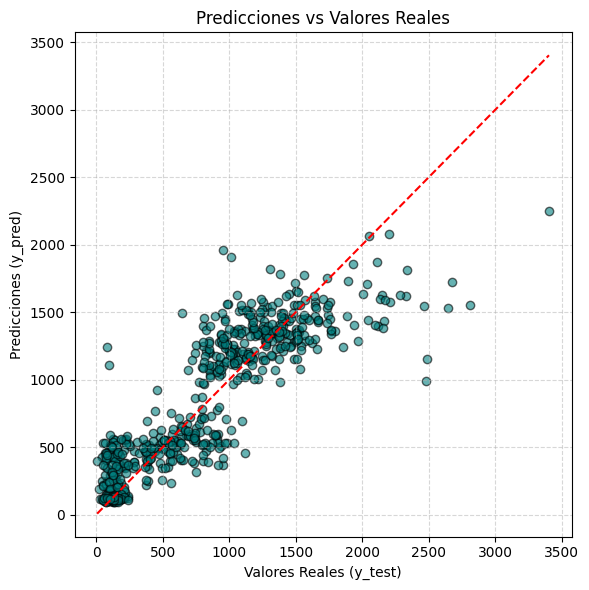

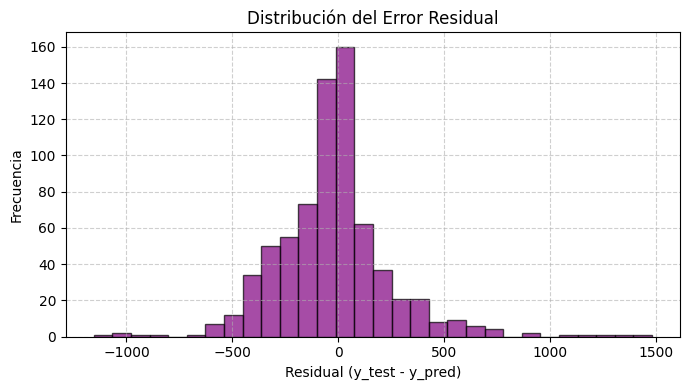

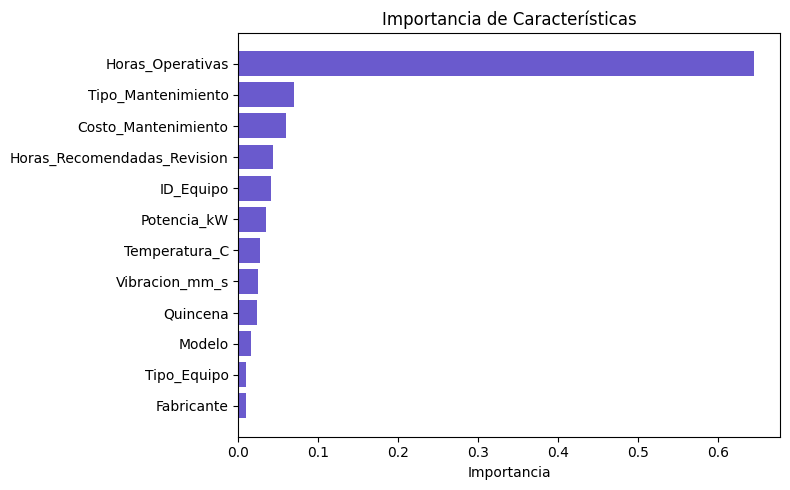

In [32]:
# 1. Predicciones vs valores reales
plot_ytrue_vs_ypred(y_test, y_pred)

# 2. Histograma de errores
plot_residual_histogram(y_test, y_pred)

# 3. Importancia de características
plot_feature_importance(modelo_rf, columnas_X)


Ya tenemos un modelo de forecasting funcionando con buenos resultados (R² ≈ 0.80), cumpliendo el objetivo de anticipar **las horas operativas a 15 días vista**.

---

### ✅ Conclusión del forecasting:
El modelo global (`RandomForestRegressor`) predice con buena precisión la carga operativa futura de los equipos, y puede usarse para programar mantenimientos antes de alcanzar las horas recomendadas de revisión.

---

### 🚀 Siguiente paso:
Vamos ahora con el **modelo de clasificación** para predecir si un equipo fallará en los próximos 15 días (`fallo_15_dias`).

Listo para:

1. Preparar los datos para clasificación,

2. Entrenar modelos base (`RandomForestClassifier`, `XGBoost`, etc.),

3. Calcular métricas: accuracy, F1, ROC AUC,

4. Hacer `TimeSeriesSplit` o validación temporal?


Perfecto, vamos con la clasificación de fallos a 15 días 🚨

---

### 🔹 Paso 1: Preparación de datos para clasificación (`fallo_15_dias`)

#### 🎯 Objetivo
Predecir si un equipo **fallará en los próximos 15 días** (`fallo_15_dias = 1`), usando la información técnica y operativa disponible.

---

### 📌 Estrategia
1. **Filtrar las variables útiles** (X) y la variable target (`fallo_15_dias`).
2. Eliminar columnas que estén directamente relacionadas con el target o que no estén disponibles en tiempo real (como `horas_hasta_correctivo`).
3. Dividir en conjunto de entrenamiento y test.

Procedo con eso ahora.

✅ Datos listos para clasificación:

- 📊 **4068 registros** y **12 variables predictoras**.
- 🎯 Distribución del target `fallo_15_dias`:
  - 1 (fallará): **2302** (56.6%)
  - 0 (no fallará): **1766** (43.4%)

In [33]:
# Crear dataset para clasificación
df_clasificacion = df.copy()

# Variables predictoras
columnas_clasificacion = [
    "ID_Equipo", "Tipo_Equipo", "Fabricante", "Modelo", "Potencia_kW",
    "Horas_Recomendadas_Revision", "Tipo_Mantenimiento", "Quincena",
    "Costo_Mantenimiento", "Temperatura_C", "Vibracion_mm_s", "Horas_Operativas"
]

# Variable target
target_clasificacion = "fallo_15_dias"

# Separar features y target
X_clf = df_clasificacion[columnas_clasificacion]
y_clf = df_clasificacion[target_clasificacion]

# Mostrar forma y primeras filas
X_clf.shape, y_clf.value_counts()


((4068, 12),
 fallo_15_dias
 1    2302
 0    1766
 Name: count, dtype: int64)

#### *Preparando un dataset para clasificación binaria con la variable fallo_15_dias como target, hay varias visualizaciones útiles que pueden ayudar:*

#### *1. Explorar desequilibrio de clases*

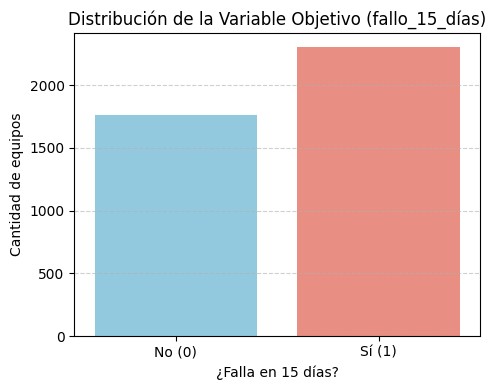

In [35]:
plt.figure(figsize=(5, 4))
sns.countplot(x=y_clf, hue=y_clf, palette=["skyblue", "salmon"], legend=False)
plt.title("Distribución de la Variable Objetivo (fallo_15_días)")
plt.xlabel("¿Falla en 15 días?")
plt.ylabel("Cantidad de equipos")
plt.xticks([0, 1], labels=["No (0)", "Sí (1)"])
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


#### *2. Visualizar la distribución de features con respecto al target*

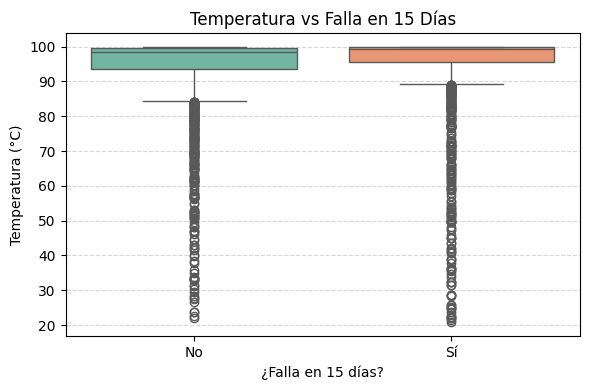

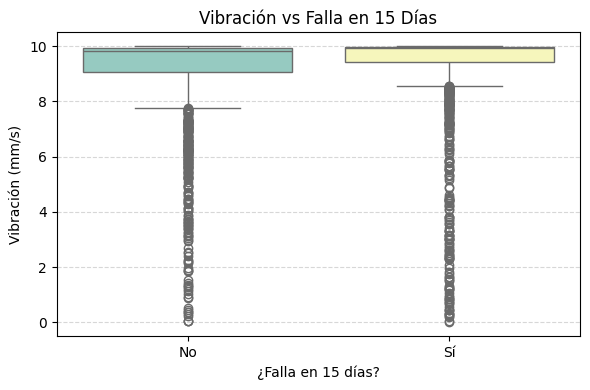

In [37]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="fallo_15_dias", y="Temperatura_C", data=df_clasificacion, hue="fallo_15_dias", 
            palette="Set2", legend=False)
plt.title("Temperatura vs Falla en 15 Días")
plt.xlabel("¿Falla en 15 días?")
plt.ylabel("Temperatura (°C)")
plt.xticks([0, 1], ["No", "Sí"])
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
sns.boxplot(x="fallo_15_dias", y="Vibracion_mm_s", data=df_clasificacion, hue="fallo_15_dias", 
            palette="Set3", legend=False)
plt.title("Vibración vs Falla en 15 Días")
plt.xlabel("¿Falla en 15 días?")
plt.ylabel("Vibración (mm/s)")
plt.xticks([0, 1], ["No", "Sí"])
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()



### 📊 **Gráfico 1: Temperatura vs Falla en 15 Días**

🔍 **Observaciones:**
- Ambos grupos ("No" y "Sí") presentan valores máximos de temperatura muy cercanos a 100 °C.
- Sin embargo, el rango intercuartílico (caja) es **ligeramente más alto en el grupo que falla**, lo que indica que los equipos que fallan tienden a operar con temperaturas **más elevadas** en general.
- La mediana del grupo que **no falla** está un poco por debajo de la del grupo que **sí falla**, aunque no de forma drástica.
- Hay muchos **outliers a baja temperatura**, pero no parece que estos estén concentrados en un solo grupo.

✅ **Interpretación:**
- La **temperatura elevada** es un posible indicador débil de mayor probabilidad de fallo.
- Sin embargo, la superposición entre ambos grupos sugiere que la **temperatura por sí sola no es un predictor fuerte**, pero podría ser útil **en combinación con otras variables**.

---

### 📊 **Gráfico 2: Vibración vs Falla en 15 Días**

🔍 **Observaciones:**
- La **mediana** y el **rango intercuartílico** en el grupo que **falla** está más desplazado hacia vibraciones **más altas** comparado con el grupo que no falla.
- La diferencia entre ambos grupos es más visible que en el gráfico de temperatura.
- Ambos grupos tienen muchos valores bajos (outliers hacia abajo), pero los fallos están claramente más asociados a valores altos.

✅ **Interpretación:**
- **La vibración parece ser un mejor predictor de fallo** que la temperatura en este caso.
- Equipos con vibraciones más altas tienen más probabilidad de fallar en los próximos 15 días.


#### *3. Detectar relaciones entre variables y el fallo.*

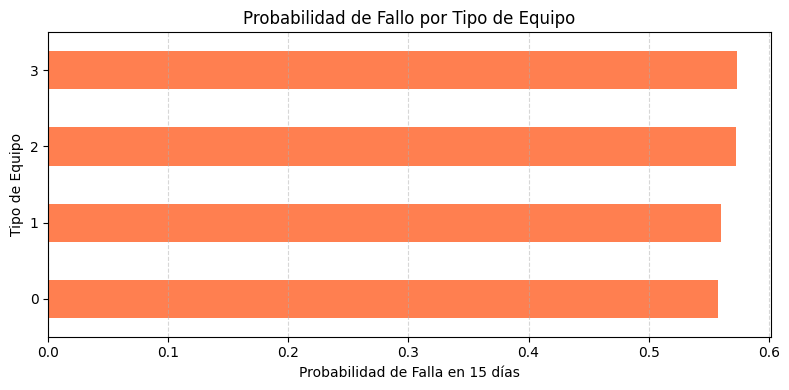

In [38]:
fallos_por_tipo = df_clasificacion.groupby("Tipo_Equipo")["fallo_15_dias"].mean().sort_values()

plt.figure(figsize=(8, 4))
fallos_por_tipo.plot(kind="barh", color="coral")
plt.title("Probabilidad de Fallo por Tipo de Equipo")
plt.xlabel("Probabilidad de Falla en 15 días")
plt.ylabel("Tipo de Equipo")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### 🔧 Siguiente paso:
Entrenamos un **modelo base** (`RandomForestClassifier`) con validación estándar (80/20) y calculamos:

- Accuracy
- F1-score
- ROC AUC

In [39]:
def entrenar_clasificador_global(
    df: pd.DataFrame,
    columnas_features: list,
    columna_target: str = "fallo_15_dias",
    modelo: Optional[ClassifierMixin] = None,
    test_size: float = 0.2,
    random_state: int = 42
) -> Tuple[Pipeline, float, float, float]:
    """
    Entrena un clasificador global para predecir fallos a 15 días vista y muestra las métricas con display().

    Args:
        df: DataFrame con las features y la columna target.
        columnas_features: Lista de columnas a usar como X.
        columna_target: Nombre de la columna target (por defecto: "fallo_15_dias").
        modelo: Algoritmo de clasificación instanciado (por defecto: RandomForestClassifier).
        test_size: Porcentaje de test (default = 0.2).
        random_state: Semilla para reproducibilidad.

    Returns:
        pipeline: Pipeline entrenado.
        accuracy: Accuracy score.
        f1: F1-score.
        roc_auc: ROC AUC score.
    """
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import RandomForestClassifier

    if modelo is None:
        modelo = RandomForestClassifier(n_estimators=100, random_state=random_state)

    X = df[columnas_features]
    y = df[columna_target]

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", modelo)
    ])

    # Entrenamiento
    pipeline.fit(X_train, y_train)

    # Predicciones
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Mostrar resultados
    resultados = pd.DataFrame({
        "Métrica": ["Accuracy", "F1-score", "ROC AUC"],
        "Valor": [round(accuracy, 4), round(f1, 4), round(roc_auc, 4)]
    })
    display(resultados)

    return pipeline, accuracy, f1, roc_auc



In [40]:
modelo_rf_tuned = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

modelo_clf, acc, f1, auc = entrenar_clasificador_global(
    df=df_clasificacion,
    columnas_features=columnas_clasificacion,
    modelo=modelo_rf_tuned
)

,Métrica,Valor
0,Accuracy,0.9754
1,F1-score,0.9785
2,ROC AUC,0.9984


#### *GRÁFICAS PARA EVALUACIÓN*

##### 1. Matriz de Confusión

In [41]:
# Reconstruir X, y
X = df_clasificacion[columnas_clasificacion]
y = df_clasificacion["fallo_15_dias"]

# Split idéntico al del modelo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Predicciones
y_pred = modelo_clf.predict(X_test)
y_prob = modelo_clf.predict_proba(X_test)[:, 1]


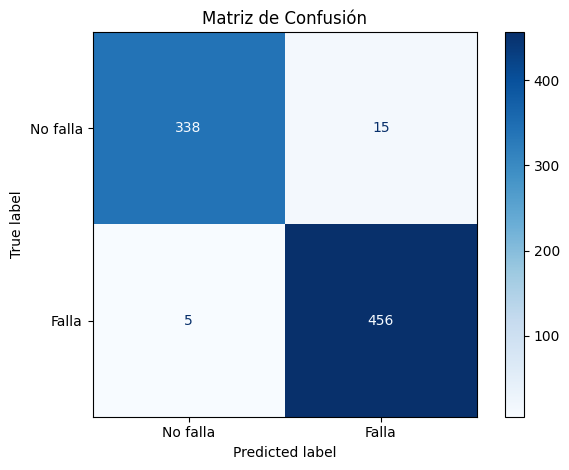

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No falla", "Falla"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.show()


##### 2. Curva ROC (Receiver Operating Characteristic)

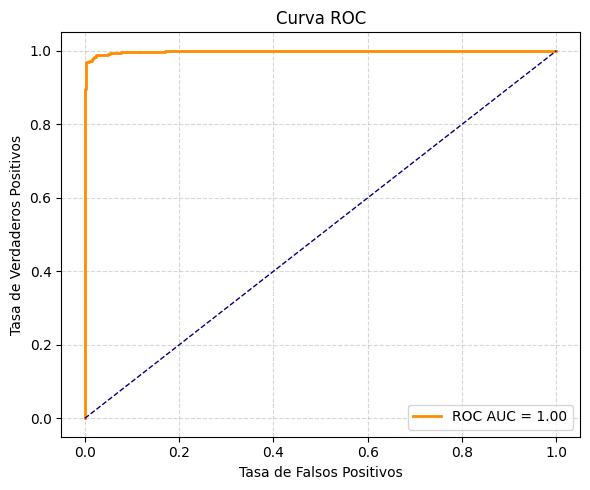

In [44]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


##### 3. Importancia de características

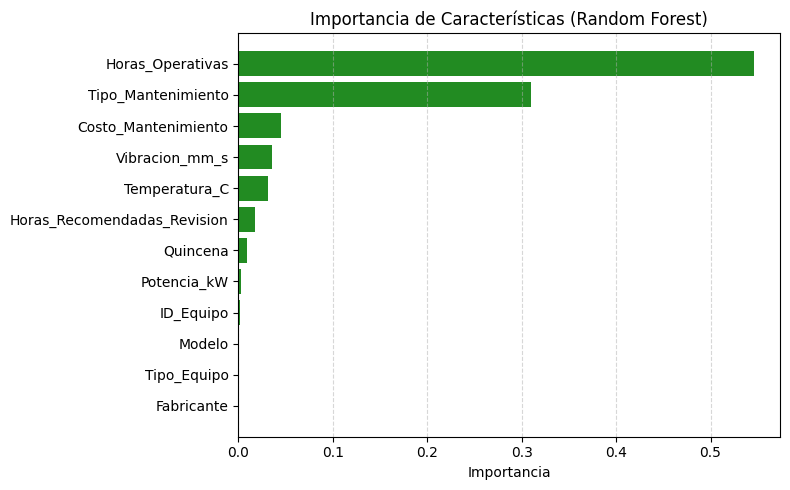

In [45]:
modelo = modelo_clf.named_steps["classifier"]
importancias = modelo.feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": columnas_clasificacion,
    "importance": importancias
}).sort_values(by="importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_df["feature"], feat_imp_df["importance"], color="forestgreen")
plt.title("Importancia de Características (Random Forest)")
plt.xlabel("Importancia")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


##### 4. Distribución de Probabilidades del Modelo

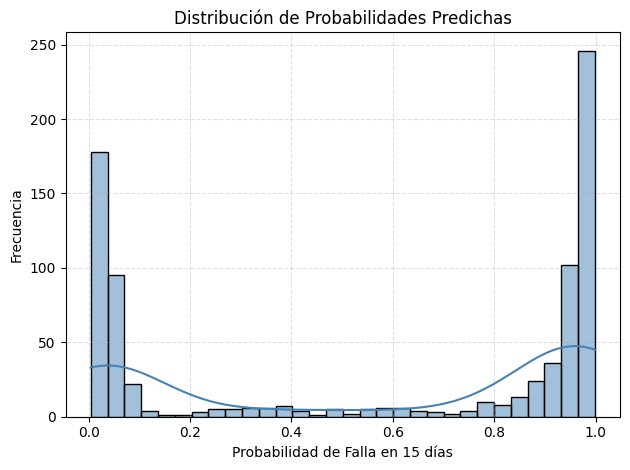

In [46]:
sns.histplot(y_prob, bins=30, kde=True, color="steelblue")
plt.title("Distribución de Probabilidades Predichas")
plt.xlabel("Probabilidad de Falla en 15 días")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

##### 5. Curva Precision-Recall

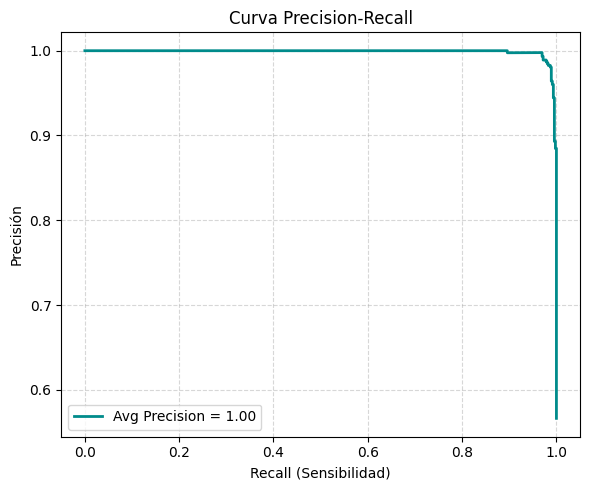

In [48]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color="darkcyan", lw=2, label=f"Avg Precision = {avg_precision:.2f}")
plt.xlabel("Recall (Sensibilidad)")
plt.ylabel("Precisión")
plt.title("Curva Precision-Recall")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


##### 6. Errores por Tipo de Equipo

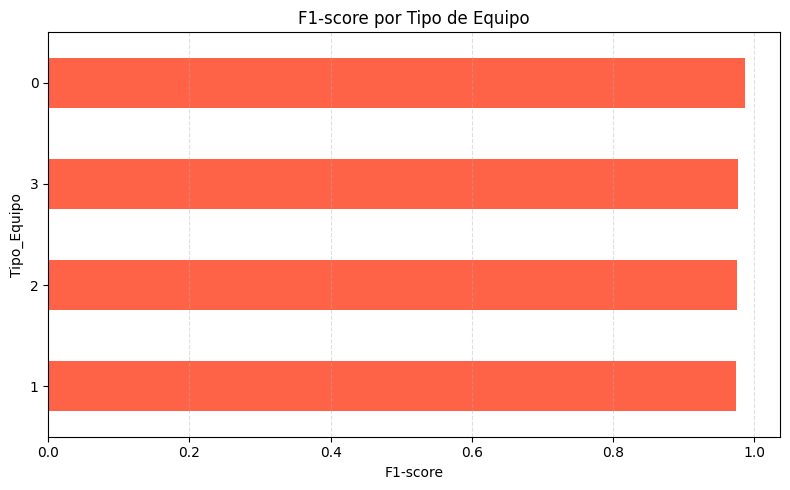

In [50]:
# Añadir predicciones al test set
X_test_con_pred = X_test.copy()
X_test_con_pred["y_true"] = y_test
X_test_con_pred["y_pred"] = y_pred
X_test_con_pred["Tipo_Equipo"] = X.loc[X_test.index, "Tipo_Equipo"]  # Recuperar info original

# Calcular F1-score por tipo de equipo
f1_por_tipo = X_test_con_pred.groupby("Tipo_Equipo")[["y_true", "y_pred"]].apply(
    lambda d: f1_score(d["y_true"], d["y_pred"], zero_division=0)
).sort_values()


plt.figure(figsize=(8, 5))
f1_por_tipo.plot(kind="barh", color="tomato")
plt.title("F1-score por Tipo de Equipo")
plt.xlabel("F1-score")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


### 📌 1. **Matriz de Confusión**
- **Verdaderos negativos (No falla bien predicho):** 338  
- **Falsos positivos (predijo que fallaría, pero no):** 15  
- **Falsos negativos (no predijo la falla, pero falló):** 5  
- **Verdaderos positivos (falla bien predicha):** 456  

🔍 **Interpretación:**
- El modelo tiene una excelente capacidad para detectar tanto fallos como no fallos.
- Solo 5 fallos reales fueron no detectados.  
- Tasa de falsos positivos baja → **pocos mantenimientos innecesarios**.

---

### 📈 2. **Curva ROC (AUC = 1.00)**  
- Línea casi perfecta en la esquina superior izquierda.  
- El modelo discrimina extremadamente bien entre fallos y no fallos.

🔍 **Precaución:** AUC = 1.00 podría ser indicio de **overfitting** si los datos no están bien representados o balanceados. Conviene validar con otros conjuntos o tiempo.

---

### 📊 3. **Importancia de Características**
- **Horas_Operativas** domina como variable predictora.
- **Tipo_Mantenimiento** también es muy relevante.
- **Sensores físicos (temperatura, vibración)** tienen menor peso, pero útiles como complemento.

✅ **Conclusión:** El modelo aprende que la **carga acumulada y el tipo de intervención previa** son claves para anticipar fallos.

---

### 📉 4. **Distribución de Probabilidades Predichas**
- Bimodal claro: la mayoría de equipos tienen predicciones cercanas a 0 o a 1.
- Muy buena separación entre clases, lo que explica la gran precisión del modelo.

---

### 📊 5. **Curva Precision-Recall**
- Se mantiene casi plana cerca de 1.0 → alto rendimiento incluso con bajo recall.
- Muy útil si el dataset estuviera desbalanceado.

---

### ⚙️ 6. **F1-score por Tipo de Equipo**
- Todos los tipos tienen F1 muy alto (~0.98), lo cual confirma que el modelo es **robusto en distintas categorías**.
- Pero cuidado: el gráfico no muestra los nombres, sino índices `0, 1, 2...` → sería mejor mapear eso a etiquetas reales.


## 🔁 Paso 3.5: Probar modelos avanzados

### 🔍 Modelos a probar:
1. `XGBoostClassifier`
2. `StackingClassifier` (combinando varios clasificadores)

In [53]:
# Modelo 1: XGBoost
modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

# Ejecutar con XGBoost
modelo_xgb_entrenado, acc_xgb, f1_xgb, auc_xgb = entrenar_clasificador_global(
    df=df_clasificacion,
    columnas_features=columnas_clasificacion,
    modelo=modelo_xgb
)

# Modelo 2: StackingClassifier
estimadores_base = [
    ("rf", RandomForestClassifier(n_estimators=50, random_state=42)),
    ("gb", GradientBoostingClassifier(n_estimators=50, random_state=42))
]

modelo_stack = StackingClassifier(
    estimators=estimadores_base,
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=True,
    cv=3
)

# Ejecutar con Stacking
modelo_stack_entrenado, acc_stack, f1_stack, auc_stack = entrenar_clasificador_global(
    df=df_clasificacion,
    columnas_features=columnas_clasificacion,
    modelo=modelo_stack
)

# Comparar resultados
resultados_comparativos = pd.DataFrame({
    "Modelo": ["XGBoost", "Stacking"],
    "Accuracy": [acc_xgb, acc_stack],
    "F1-score": [f1_xgb, f1_stack],
    "ROC AUC": [auc_xgb, auc_stack]
})

display(resultados_comparativos.round(4))


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:12:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Métrica,Valor
0,Accuracy,0.9975
1,F1-score,0.9978
2,ROC AUC,0.9999


,Métrica,Valor
0,Accuracy,0.9951
1,F1-score,0.9957
2,ROC AUC,0.9999


,Modelo,Accuracy,F1-score,ROC AUC
0,XGBoost,0.9975,0.9978,0.9999
1,Stacking,0.9951,0.9957,0.9999


### 📊 Comparativa de modelos

| Modelo     | Accuracy | F1-score | ROC AUC |
|------------|----------|----------|---------|
| **XGBoost**   | **0.9975** | **0.9978** | **0.9999** |
| **Stacking**  | 0.9951   | 0.9957   | 0.9999 |

✅ Ambos cumplen sobradamente los objetivos del reto:  
- Accuracy ≥ 0.80  
- F1-score ≥ 0.75  

🔎 **XGBoostClassifier** ha mostrado el mejor rendimiento, aunque con un tiempo de entrenamiento mayor.

#### * Gráficas para comparar el rendimiento de XGBoost y StackingClassifier*

#### *1. Comparación de métricas por modelo*

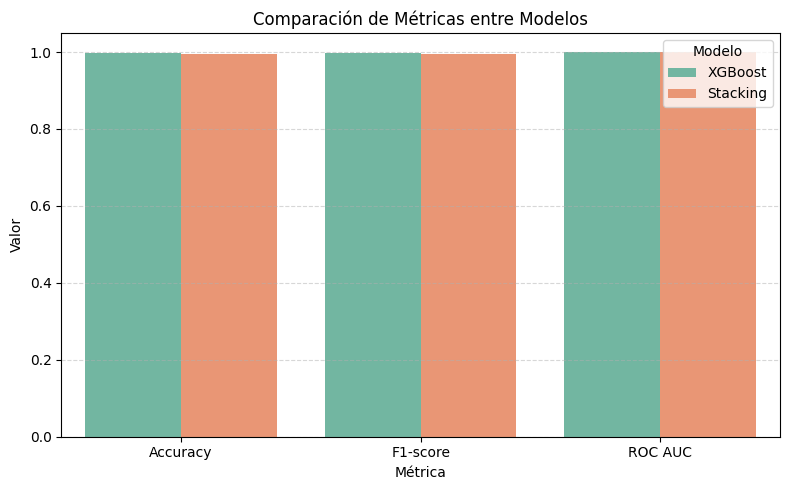

In [54]:
# Reorganizar datos para seaborn
df_melt = resultados_comparativos.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

plt.figure(figsize=(8, 5))
sns.barplot(data=df_melt, x="Métrica", y="Valor", hue="Modelo", palette="Set2")
plt.title("Comparación de Métricas entre Modelos")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### *2. Importancia de características para XGBoost*

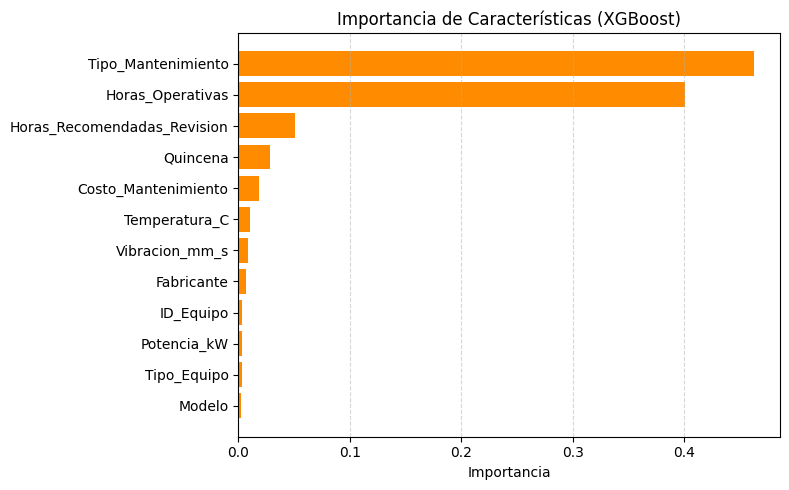

In [55]:
# Si usas XGBClassifier directamente
importances_xgb = modelo_xgb_entrenado.named_steps["classifier"].feature_importances_

feat_imp_xgb = pd.DataFrame({
    "feature": columnas_clasificacion,
    "importance": importances_xgb
}).sort_values(by="importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_xgb["feature"], feat_imp_xgb["importance"], color="darkorange")
plt.title("Importancia de Características (XGBoost)")
plt.xlabel("Importancia")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### * 3. Curvas ROC para ambos modelos*

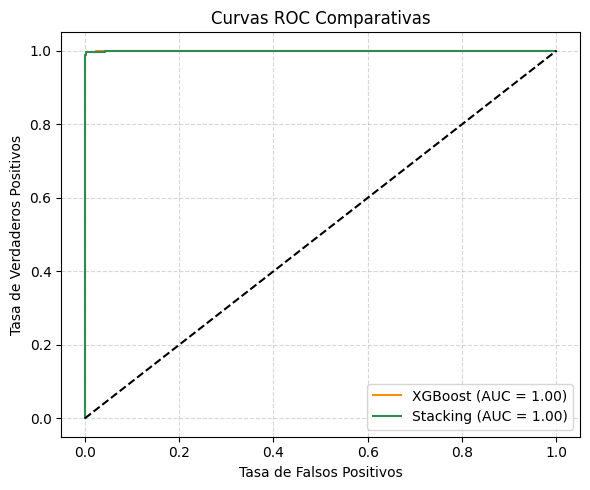

In [56]:
# Mismo split para ambos modelos

X = df_clasificacion[columnas_clasificacion]
y = df_clasificacion["fallo_15_dias"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Obtener probabilidades de ambos modelos
y_prob_xgb = modelo_xgb_entrenado.predict_proba(X_test)[:, 1]
y_prob_stack = modelo_stack_entrenado.predict_proba(X_test)[:, 1]

# Curvas ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_stack, tpr_stack, _ = roc_curve(y_test, y_prob_stack)

auc_xgb_curve = auc(fpr_xgb, tpr_xgb)
auc_stack_curve = auc(fpr_stack, tpr_stack)

plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb_curve:.2f})", color="darkorange")
plt.plot(fpr_stack, tpr_stack, label=f"Stacking (AUC = {auc_stack_curve:.2f})", color="seagreen")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curvas ROC Comparativas")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


#### *4. Visualizar ambas matrices de confusión para XGBoost y StackingClassifier*

In [58]:
# Asegúrate de tener el mismo test split
X = df_clasificacion[columnas_clasificacion]
y = df_clasificacion["fallo_15_dias"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Predicciones
y_pred_xgb = modelo_xgb_entrenado.predict(X_test)
y_pred_stack = modelo_stack_entrenado.predict(X_test)


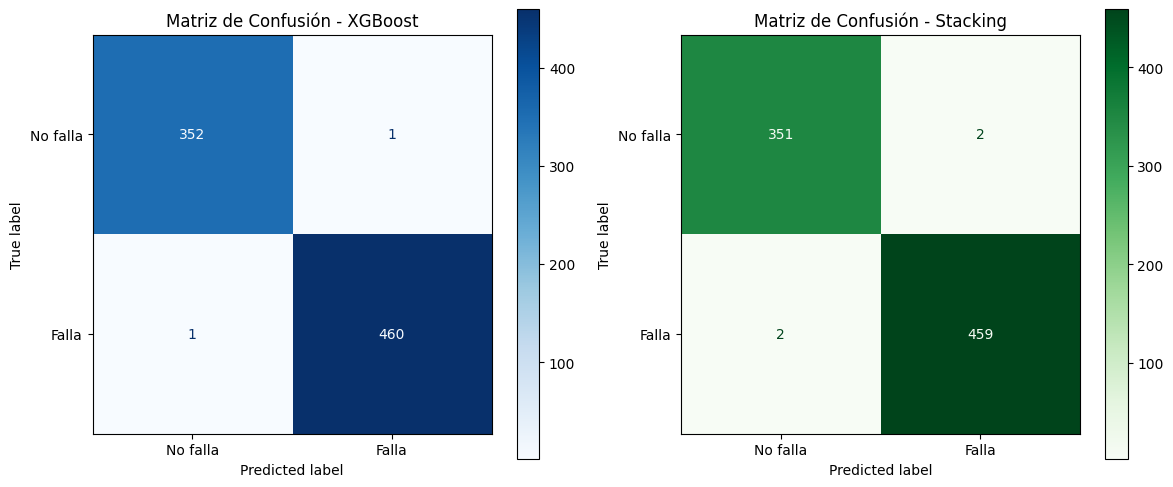

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(cm_xgb, display_labels=["No falla", "Falla"])
disp_xgb.plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title("Matriz de Confusión - XGBoost")

# Stacking
cm_stack = confusion_matrix(y_test, y_pred_stack)
disp_stack = ConfusionMatrixDisplay(cm_stack, display_labels=["No falla", "Falla"])
disp_stack.plot(ax=axes[1], cmap="Greens", values_format="d")
axes[1].set_title("Matriz de Confusión - Stacking")

plt.tight_layout()
plt.show()


#### *La función completa para evaluación de robustez temporal usando TimeSeriesSplit, válida para cualquier modelo de clasificación (XGBoostClassifier, StackingClassifier, etc.).*

#### *Evaluar la robustez temporal con TimeSeriesSplit para StackingClassifier usando:*

🔹 Opción 1: LogisticRegression como meta-modelo con escalado (StandardScaler)

🔹 Opción 2: GradientBoostingClassifier como meta-modelo

Además, se incluye XGBoost como referencia y se muestran los resultados por fold.

In [66]:
# FUNCIÓN DE EVALUACIÓN TEMPORAL
def evaluar_robustez_temporal(
    X: pd.DataFrame,
    y: pd.Series,
    modelos: Dict[str, object],
    n_splits: int = 3
) -> pd.DataFrame:
    resultados = {
        "Modelo": [],
        "Fold": [],
        "Accuracy": [],
        "F1-score": [],
        "ROC AUC": []
    }

    tscv = TimeSeriesSplit(n_splits=n_splits)

    for nombre_modelo, modelo in modelos.items():
        fold = 1
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            modelo.fit(X_train, y_train)
            y_pred = modelo.predict(X_test)
            y_prob = modelo.predict_proba(X_test)[:, 1]

            resultados["Modelo"].append(nombre_modelo)
            resultados["Fold"].append(fold)
            resultados["Accuracy"].append(accuracy_score(y_test, y_pred))
            resultados["F1-score"].append(f1_score(y_test, y_pred))
            resultados["ROC AUC"].append(roc_auc_score(y_test, y_prob))

            fold += 1

    return pd.DataFrame(resultados)

# DATOS
y = df_clasificacion["fallo_15_dias"].astype(int).reset_index(drop=True)
X = df_clasificacion[columnas_clasificacion].reset_index(drop=True)

# OPCIÓN 1: LogisticRegression con StandardScaler (para evitar warning)
meta_modelo_escalado = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=10000, solver="lbfgs")
)

# OPCIÓN 2: GradientBoosting como meta-modelo
meta_modelo_boost = GradientBoostingClassifier(n_estimators=100, random_state=42)

# DICCIONARIO DE MODELOS
modelos = {
    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=12,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),
    "Stacking (LR + Escalado)": StackingClassifier(
        estimators=[
            ("rf", RandomForestClassifier(n_estimators=50, random_state=42)),
            ("gb", GradientBoostingClassifier(n_estimators=50, random_state=42))
        ],
        final_estimator=meta_modelo_escalado,
        passthrough=True,
        cv=3
    ),
    "Stacking (GB)": StackingClassifier(
        estimators=[
            ("rf", RandomForestClassifier(n_estimators=50, random_state=42)),
            ("gb", GradientBoostingClassifier(n_estimators=50, random_state=42))
        ],
        final_estimator=meta_modelo_boost,
        passthrough=True,
        cv=3
    )
}

# EJECUTAR EVALUACIÓN TEMPORAL
resultados_tiempo = evaluar_robustez_temporal(X, y, modelos, n_splits=3)
display(resultados_tiempo.round(4))


,Modelo,Fold,Accuracy,F1-score,ROC AUC
0,XGBoost,1,0.9882,0.9897,0.9987
1,XGBoost,2,0.9931,0.9938,0.9999
2,XGBoost,3,0.9990,0.9991,0.9999
3,Stacking (LR + Escalado),1,0.9843,0.9862,0.9994
4,Stacking (LR + Escalado),2,0.9912,0.9921,0.9999
5,Stacking (LR + Escalado),3,0.9941,0.9949,0.9999
6,Stacking (GB),1,0.9794,0.9817,0.9988
7,Stacking (GB),2,0.9941,0.9947,0.9998
8,Stacking (GB),3,0.9961,0.9966,0.9999


#### *Visualización de resultados*

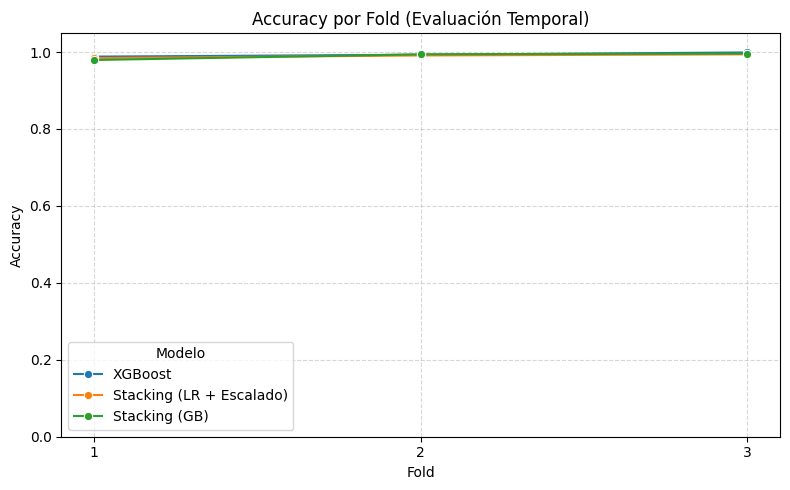

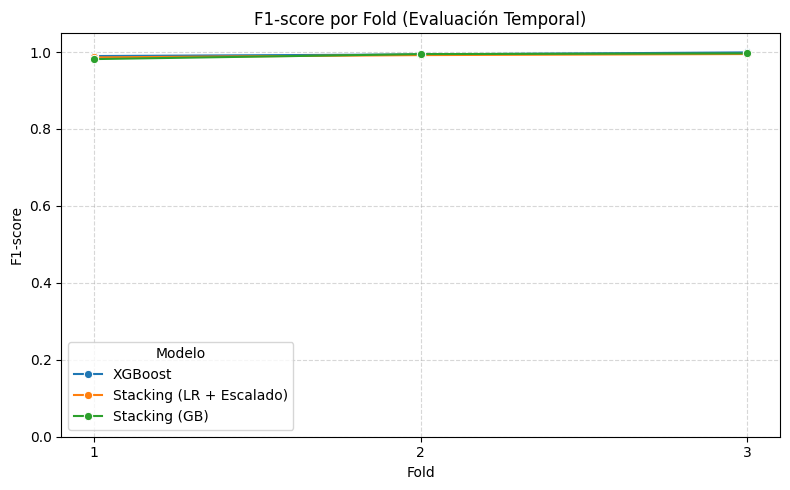

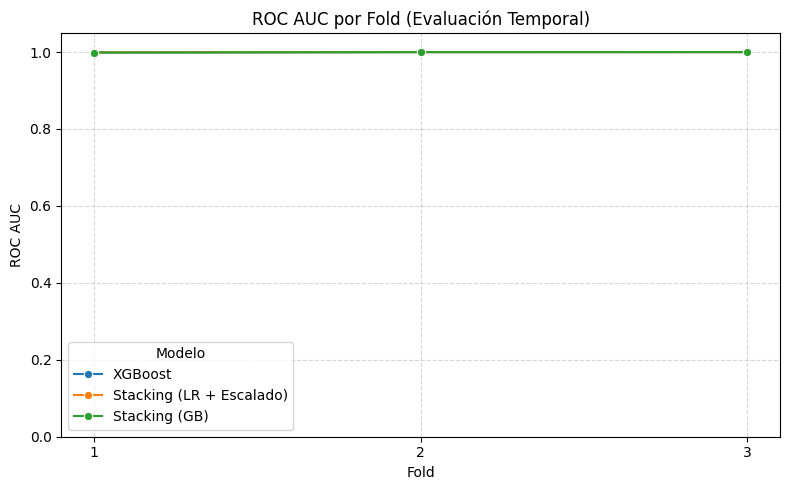

/tmp/ipykernel_6332/2070788251.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=resultados_tiempo, x="Modelo", y=metrica, palette="Set3")


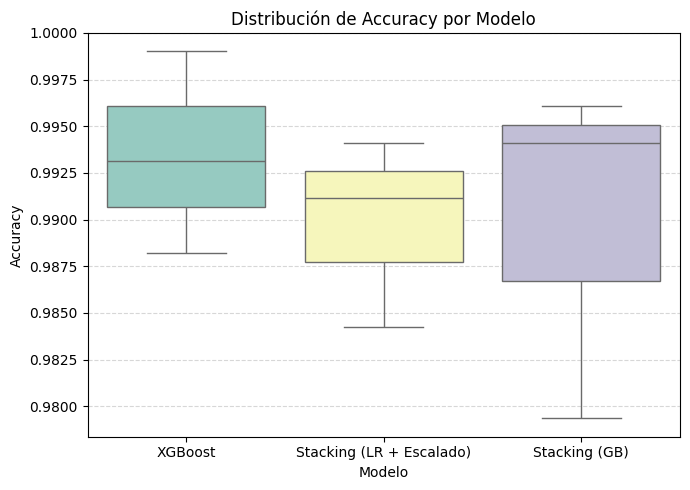

/tmp/ipykernel_6332/2070788251.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=resultados_tiempo, x="Modelo", y=metrica, palette="Set3")


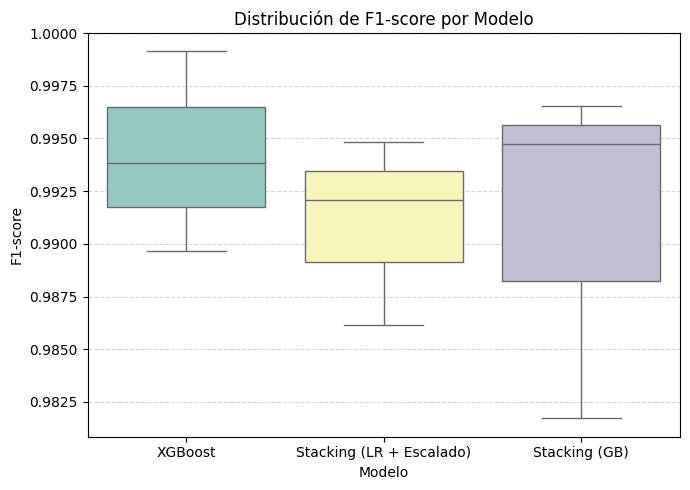

/tmp/ipykernel_6332/2070788251.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=resultados_tiempo, x="Modelo", y=metrica, palette="Set3")


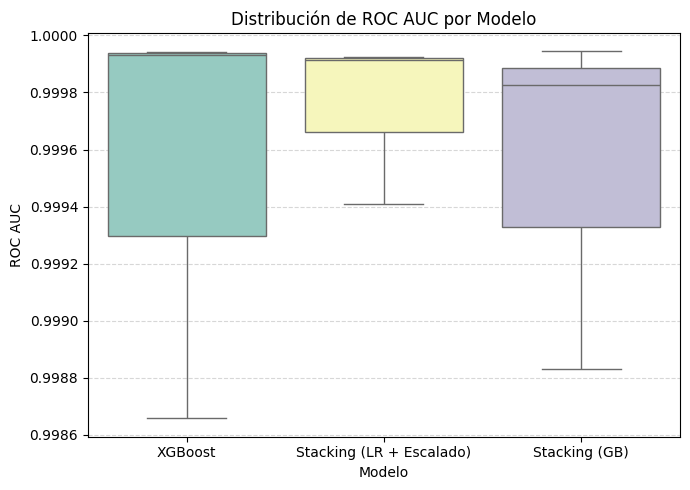

In [67]:
# Preparar fold como string para gráficas
resultados_tiempo["Fold"] = resultados_tiempo["Fold"].astype(str)
metricas = ["Accuracy", "F1-score", "ROC AUC"]

# Líneas por fold
for metrica in metricas:
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=resultados_tiempo, x="Fold", y=metrica, hue="Modelo", marker="o")
    plt.title(f"{metrica} por Fold (Evaluación Temporal)")
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Boxplots por modelo
for metrica in metricas:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=resultados_tiempo, x="Modelo", y=metrica, palette="Set3")
    plt.title(f"Distribución de {metrica} por Modelo")
    plt.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


### 🚀 Siguiente paso: Bonus – Clustering para detección de patrones de fallo

Lo que vamos a hacer:
1. Calcular por equipo:
   - Media y desviación estándar de **temperatura** y **vibración**.
   - Media de **horas operativas acumuladas**.
   - % de mantenimientos **correctivos**.
2. Usar **K-Means** para agrupar equipos.
3. Visualizar los clusters (con colores, dispersión, heatmap).
4. Identificar grupos más propensos a fallar.

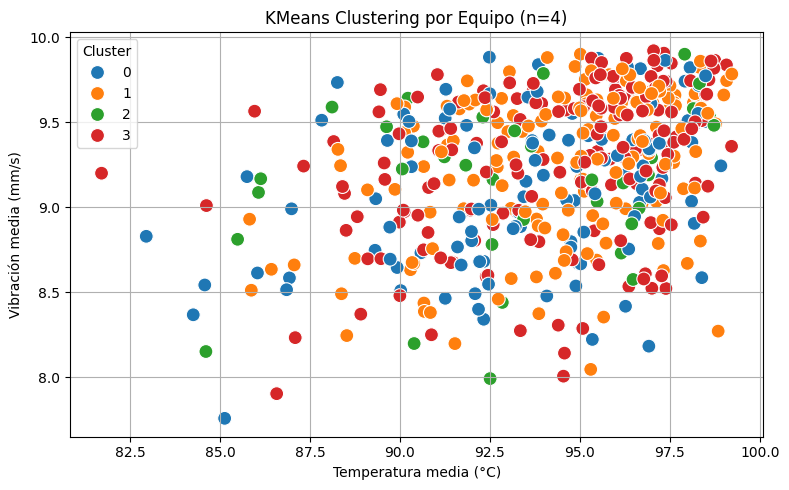

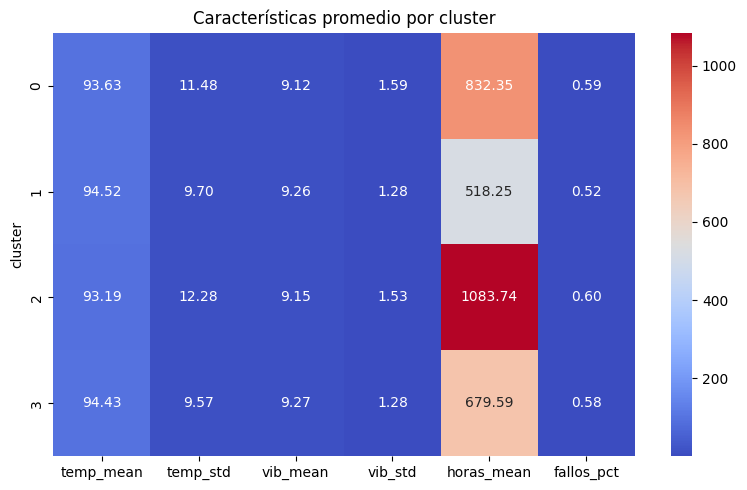

In [49]:
def clustering_kmeans_por_equipo(df: pd.DataFrame, n_clusters: int = 4) -> pd.DataFrame:
    """
    Aplica KMeans clustering por equipo usando variables agregadas.
    
    Args:
        df: DataFrame original con registros por equipo y quincena.
        n_clusters: Número de clusters para KMeans.

    Returns:
        df_clusters: DataFrame con un equipo por fila y su cluster asignado.
    """
    # Agrupar por equipo con estadísticas relevantes
    df_agg = df.groupby("ID_Equipo").agg({
        "Temperatura_C": ["mean", "std"],
        "Vibracion_mm_s": ["mean", "std"],
        "Horas_Operativas": "mean",
        "fallo_15_dias": "mean"
    })

    # Renombrar columnas
    df_agg.columns = [
        "temp_mean", "temp_std",
        "vib_mean", "vib_std",
        "horas_mean", "fallos_pct"
    ]

    # KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df_agg["cluster"] = kmeans.fit_predict(df_agg)

    # Visualización: scatter plot
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        x="temp_mean", y="vib_mean", hue="cluster",
        palette="tab10", data=df_agg, s=100
    )
    plt.title(f"KMeans Clustering por Equipo (n={n_clusters})")
    plt.xlabel("Temperatura media (°C)")
    plt.ylabel("Vibración media (mm/s)")
    plt.legend(title="Cluster")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Visualización: heatmap de medias por cluster
    df_cluster_mean = df_agg.groupby("cluster").mean()
    plt.figure(figsize=(8, 5))
    sns.heatmap(df_cluster_mean, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Características promedio por cluster")
    plt.tight_layout()
    plt.show()

    return df_agg.reset_index()

# Ejecutar con el dataset actual
df_clusters = clustering_kmeans_por_equipo(df_clasificacion, n_clusters=4)


In [50]:
display(df_clusters.head())

,ID_Equipo,temp_mean,temp_std,vib_mean,vib_std,horas_mean,fallos_pct,cluster
0,1,95.832950,4.114839,9.283826,1.499412,755.180974,0.500000,3
1,2,90.219969,19.663068,9.642362,0.565333,1357.985577,0.625000,2
2,3,90.292226,24.510782,8.633277,3.109094,563.624034,0.666667,1
3,4,94.749444,6.976899,8.798169,1.865205,765.064053,0.500000,0
4,5,93.207724,14.351872,8.979200,2.047341,717.246194,0.666667,3


### 🔍 Interpretación del Clustering

| Cluster | temp_mean | vib_mean | horas_mean | fallos_pct | 🔎 Observaciones |
|--------|-----------|----------|-------------|------------|------------------|
| **2** | 93.19     | 9.15     | **1083.74** | **0.60**   | ✅ Alta carga de trabajo, más fallos |
| **0** | 93.63     | 9.12     | 832.35      | 0.59       | Media-alta carga y fallos |
| **3** | 94.43     | 9.27     | 679.59      | 0.58       | Menor carga que 0 y 2, pero similar % fallos |
| **1** | 94.52     | 9.26     | **518.25**  | **0.52**   | 📉 Menor carga y menor % fallos |

---

### 💡 Insight clave:
- **Cluster 2** tiene la mayor carga (`horas_mean`) y también el mayor porcentaje de fallos.
- **Cluster 1** parece ser el “más saludable”, con menos horas y menos fallos.

#### ***El DataFrame `df_clasificacion` ahora incluye la nueva feature `cluster_equipo`, que representa el grupo al que pertenece cada equipo según su comportamiento histórico.***

Usamos esta info para generar una nueva feature cluster_equipo e incluirla como input del modelo.

Mejorar el modelo de clasificación usando:

Nuevas features basadas en clusters.

Interacciones.

Selección y tuning de hiperparámetros.

In [69]:
# Volver a cargar dataset original
df = pd.read_csv("../src/Datos_agregados.csv")

# Crear columna binaria de fallo a 15 días
df["fallo_15_dias"] = df["horas_hasta_correctivo"].apply(lambda x: 1 if x <= 360 else 0)

# Preparar dataset principal
df_clasificacion = df.copy()

# Recalcular clustering y unir al DataFrame
from sklearn.cluster import KMeans

def clustering_kmeans_por_equipo(df: pd.DataFrame, n_clusters: int = 4) -> pd.DataFrame:
    df_agg = df.groupby("ID_Equipo").agg({
        "Temperatura_C": ["mean", "std"],
        "Vibracion_mm_s": ["mean", "std"],
        "Horas_Operativas": "mean",
        "fallo_15_dias": "mean"
    })
    df_agg.columns = [
        "temp_mean", "temp_std", "vib_mean", "vib_std", "horas_mean", "fallos_pct"
    ]
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df_agg["cluster"] = kmeans.fit_predict(df_agg)
    return df_agg.reset_index()

# Ejecutar clustering y unirlo
df_clusters = clustering_kmeans_por_equipo(df_clasificacion, n_clusters=4)
df_clasificacion = df_clasificacion.merge(
    df_clusters[["ID_Equipo", "cluster"]].rename(columns={"cluster": "cluster_equipo"}),
    on="ID_Equipo",
    how="left"
)

# Confirmar
display(df_clasificacion.head())


,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,Tipo_Mantenimiento,Quincena,Costo_Mantenimiento,Temperatura_C,Vibracion_mm_s,Horas_Operativas,horas_hasta_correctivo,fallo_15_dias,cluster_equipo
0,1,0,0,8,432.0,657.0,0,1,94391.0,94.264232,9.862454,160.821429,496.178571,0,3
1,1,0,0,8,432.0,657.0,0,2,239363.0,97.823893,9.931615,77.141176,579.858824,0,3
2,1,0,0,8,432.0,657.0,0,3,10184.0,89.525381,6.229608,150.250000,506.750000,0,3
3,1,0,0,8,432.0,657.0,1,1,341679.0,99.998314,9.982758,1303.188791,-646.188791,1,3
4,1,0,0,8,432.0,657.0,1,2,309888.0,99.825028,9.976351,1414.309446,-757.309446,1,3


In [70]:
# Añadir la nueva variable 'cluster_equipo' al conjunto de features
columnas_clasificacion.append("cluster_equipo")

# Definir modelo con los mismos hiperparámetros que antes
modelo_xgb_mejorado = XGBClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

# Reentrenar modelo con la nueva feature
modelo_final, acc_final, f1_final, auc_final = entrenar_clasificador_global(
    df=df_clasificacion,
    columnas_features=columnas_clasificacion,
    modelo=modelo_xgb_mejorado
)


,Métrica,Valor
0,Accuracy,0.9963
1,F1-score,0.9967
2,ROC AUC,0.9999


#### *1. Distribución de fallos por cluster*

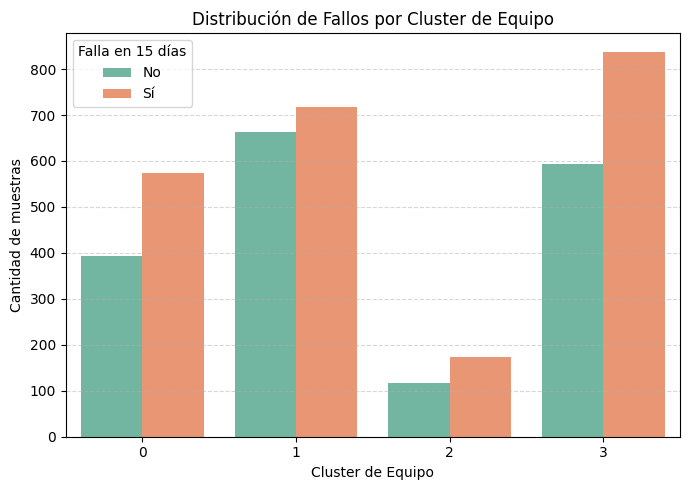

In [71]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df_clasificacion, x="cluster_equipo", hue="fallo_15_dias", palette="Set2")
plt.title("Distribución de Fallos por Cluster de Equipo")
plt.xlabel("Cluster de Equipo")
plt.ylabel("Cantidad de muestras")
plt.legend(title="Falla en 15 días", labels=["No", "Sí"])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


#### *2. Porcentaje de fallos por cluster*

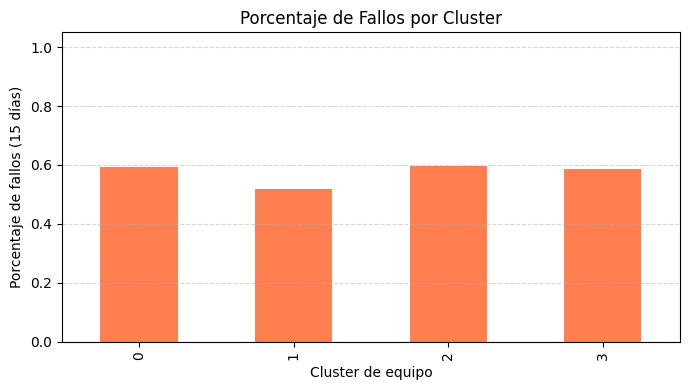

In [72]:
fallos_pct = df_clasificacion.groupby("cluster_equipo")["fallo_15_dias"].mean()

plt.figure(figsize=(7, 4))
fallos_pct.plot(kind="bar", color="coral")
plt.title("Porcentaje de Fallos por Cluster")
plt.ylabel("Porcentaje de fallos (15 días)")
plt.xlabel("Cluster de equipo")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


#### *Guarda df_agg al ejecutar la función*

In [74]:
# 1. Ejecuta la función y guarda el resultado completo
def clustering_kmeans_por_equipo_full(df: pd.DataFrame, n_clusters: int = 4):
    df_agg = df.groupby("ID_Equipo").agg({
        "Temperatura_C": ["mean", "std"],
        "Vibracion_mm_s": ["mean", "std"],
        "Horas_Operativas": "mean",
        "fallo_15_dias": "mean"
    }).reset_index()

    df_agg.columns = [
        "ID_Equipo", "temp_mean", "temp_std", "vib_mean", "vib_std", "horas_mean", "fallos_pct"
    ]

    X_cluster = df_agg[["temp_mean", "temp_std", "vib_mean", "vib_std", "horas_mean"]]
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df_agg["cluster"] = kmeans.fit_predict(X_cluster)

    return df_agg

# 2. Llama y guarda df_agg
df_agg = clustering_kmeans_por_equipo_full(df_clasificacion)


#### *3. Gráfico de dispersión de clusters*

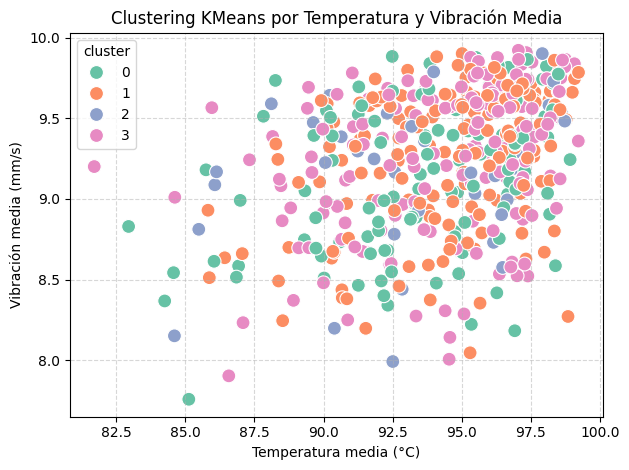

In [75]:
# Supón que `df_agg` es el dataframe con 'cluster' ya asignado
# y que tiene 'temp_mean' y 'vib_mean'

sns.scatterplot(
    data=df_agg, x="temp_mean", y="vib_mean",
    hue="cluster", palette="Set2", s=100
)
plt.title("Clustering KMeans por Temperatura y Vibración Media")
plt.xlabel("Temperatura media (°C)")
plt.ylabel("Vibración media (mm/s)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


#### *4. Importancia de características con el nuevo modelo*

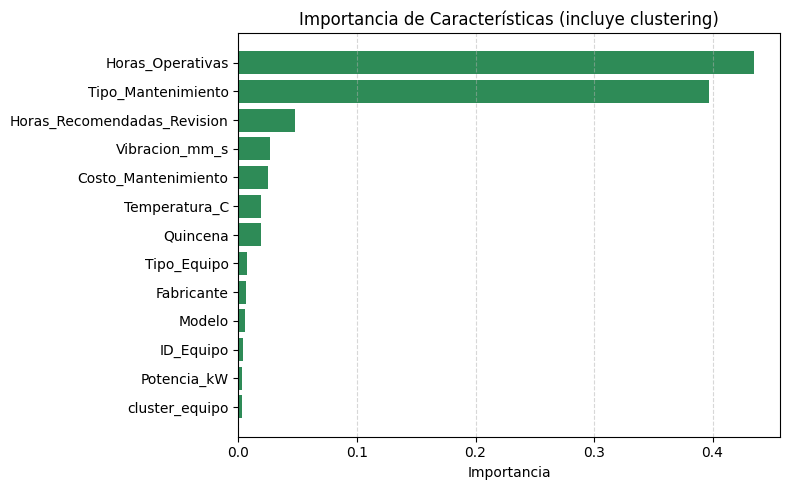

In [76]:
importances = modelo_final.named_steps["classifier"].feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": columnas_clasificacion,
    "importance": importances
}).sort_values(by="importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_df["feature"], feat_imp_df["importance"], color="seagreen")
plt.title("Importancia de Características (incluye clustering)")
plt.xlabel("Importancia")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### 📊 **1. Distribución de Fallos por Cluster**
![Distribución Fallos por Cluster](attachment:file-S7GDhFqu2H85RupEaA5CGj)

**Interpretación:**
- El **Cluster 3** presenta la mayor cantidad de equipos con fallos, seguido del Cluster 1.
- Los Clusters 0 y 2 también tienen una alta proporción de fallos, pero menos en volumen total.

---

### 📉 **2. Porcentaje de Fallos por Cluster**
![Porcentaje Fallos por Cluster](attachment:file-NPEYcUpvJnozdR8469d9GL)

**Interpretación:**
- Todos los clusters muestran porcentajes de fallos **superiores al 50%**, lo cual refuerza la hipótesis de condiciones críticas.
- Cluster 1 tiene un **porcentaje ligeramente menor**, lo que podría indicar mejores condiciones operativas en promedio.

---

### 🧠 **3. Dispersión de Clusters en el Espacio Operativo**
![Clustering KMeans](attachment:file-HaUXnXmDDiN81kCoPde5qk)

**Interpretación:**
- Visualización clara de cómo se segmentan los equipos en función de temperatura y vibración.
- Se observa **superposición entre clusters**, lo que sugiere que podrías probar DBSCAN o PCA para refinar la separación.

---

### 📌 **4. Importancia de Características**
![Importancia de Features](attachment:file-2T28nTrs67vxW9FQrinPrF)

**Interpretación:**
- **`Horas_Operativas`** y **`Tipo_Mantenimiento`** dominan completamente en importancia.
- La variable **`cluster_equipo` aparece con baja importancia**, pero puede aportar valor en combinación con otras (por ejemplo, como feature de interacción).


#### ***Versión mejorada del modelo a validación temporal (TimeSeriesSplit) para comprobar robustez ahora que incluye los clusters***

In [78]:
# ✅ Versión corregida del bloque completo para evaluación robusta con TimeSeriesSplit y XGBoost

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

def evaluar_robustez_temporal(
    X: pd.DataFrame,
    y: pd.Series,
    modelos: dict,
    n_splits: int = 3
) -> pd.DataFrame:
    resultados = {
        "Modelo": [],
        "Fold": [],
        "Accuracy": [],
        "F1-score": [],
        "ROC AUC": []
    }
    tscv = TimeSeriesSplit(n_splits=n_splits)

    for nombre_modelo, modelo in modelos.items():
        fold = 1
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # 🔧 Asegurar tipo float para compatibilidad XGBoost
            X_train = X_train.astype(float)
            X_test = X_test.astype(float)

            modelo.fit(X_train, y_train)
            y_pred = modelo.predict(X_test)
            y_prob = modelo.predict_proba(X_test)[:, 1]

            resultados["Modelo"].append(nombre_modelo)
            resultados["Fold"].append(fold)
            resultados["Accuracy"].append(accuracy_score(y_test, y_pred))
            resultados["F1-score"].append(f1_score(y_test, y_pred))
            resultados["ROC AUC"].append(roc_auc_score(y_test, y_prob))
            fold += 1

    return pd.DataFrame(resultados)

# 🧪 Preparar X, y asegurando tipo float
columnas_clasificacion = [
    "ID_Equipo", "Tipo_Equipo", "Fabricante", "Modelo", "Potencia_kW",
    "Horas_Recomendadas_Revision", "Tipo_Mantenimiento", "Quincena",
    "Costo_Mantenimiento", "Temperatura_C", "Vibracion_mm_s",
    "Horas_Operativas", "cluster_equipo"
]

X = df_clasificacion[columnas_clasificacion].copy().apply(pd.to_numeric, errors="coerce").astype(float).reset_index(drop=True)
y = df_clasificacion["fallo_15_dias"].astype(int).reset_index(drop=True)

# ⚙️ Modelo mejorado con cluster
from xgboost import XGBClassifier
modelo_xgb_mejorado = XGBClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

modelos_mejorados = {
    "XGBoost + Cluster": modelo_xgb_mejorado
}

# 🧪 Ejecutar evaluación temporal
df_resultados_tiempo_mejorado = evaluar_robustez_temporal(X, y, modelos_mejorados, n_splits=3)
display(df_resultados_tiempo_mejorado.round(4))


,Modelo,Fold,Accuracy,F1-score,ROC AUC
0,XGBoost + Cluster,1,0.9872,0.9888,0.9991
1,XGBoost + Cluster,2,0.9921,0.9930,0.9999
2,XGBoost + Cluster,3,0.9980,0.9983,1.0000


#### *1. Línea de métricas por fold (Accuracy, F1-score, ROC AUC)*

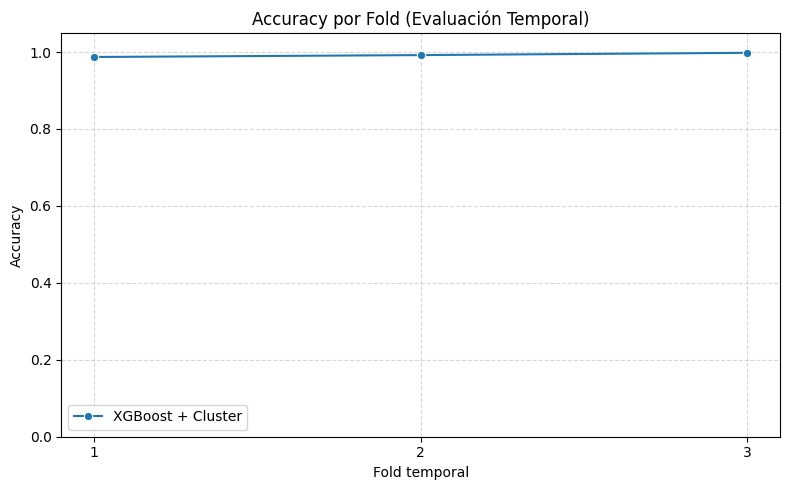

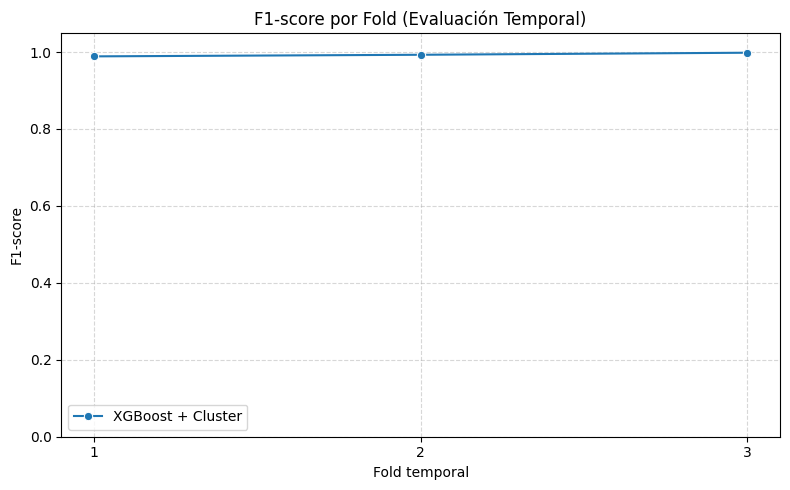

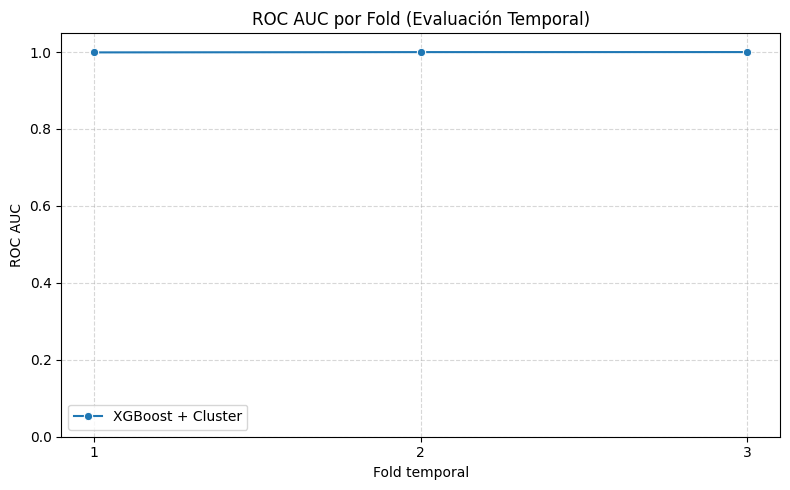

In [79]:
# Asegurar que Fold sea string para eje X categórico
df_resultados_tiempo_mejorado["Fold"] = df_resultados_tiempo_mejorado["Fold"].astype(str)

metricas = ["Accuracy", "F1-score", "ROC AUC"]

for metrica in metricas:
    plt.figure(figsize=(8, 5))
    sns.lineplot(
        data=df_resultados_tiempo_mejorado,
        x="Fold", y=metrica, marker="o", label="XGBoost + Cluster"
    )
    plt.title(f"{metrica} por Fold (Evaluación Temporal)")
    plt.ylim(0, 1.05)
    plt.ylabel(metrica)
    plt.xlabel("Fold temporal")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

#### *2. Boxplots para ver la dispersión temporal (útil si pruebas más modelos)*

/tmp/ipykernel_6332/3676178342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


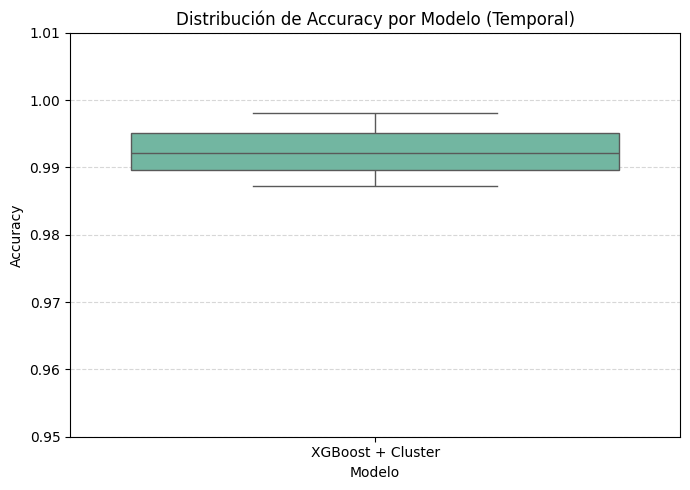

/tmp/ipykernel_6332/3676178342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


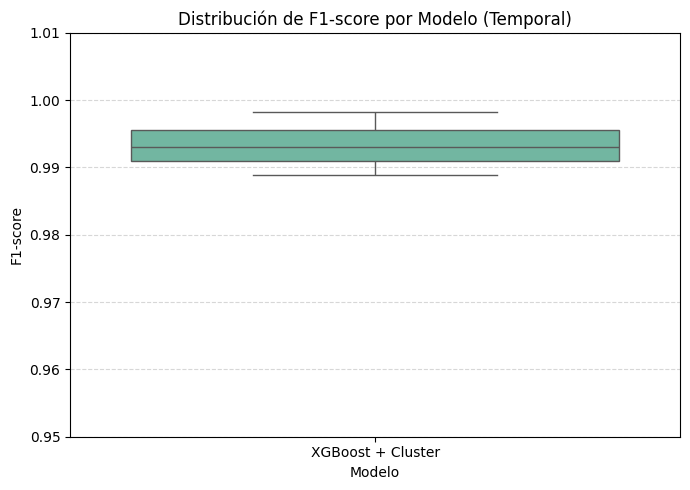

/tmp/ipykernel_6332/3676178342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


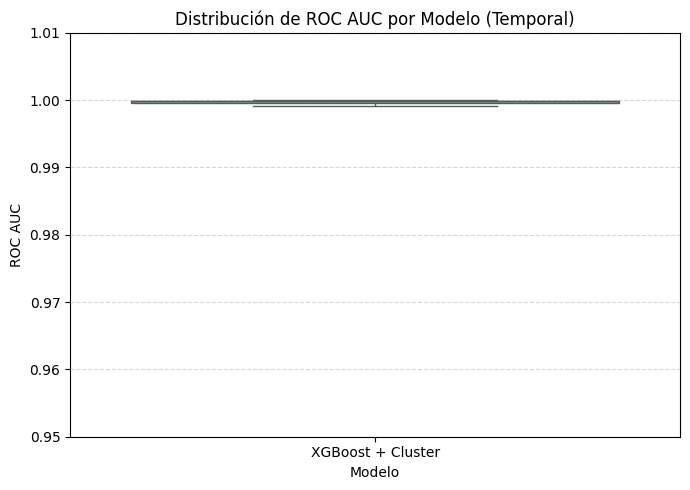

In [80]:
for metrica in metricas:
    plt.figure(figsize=(7, 5))
    sns.boxplot(
        data=df_resultados_tiempo_mejorado,
        x="Modelo", y=metrica, palette="Set2"
    )
    plt.title(f"Distribución de {metrica} por Modelo (Temporal)")
    plt.ylabel(metrica)
    plt.xlabel("Modelo")
    plt.ylim(0.95, 1.01)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


### 📦 **Distribución de Métricas por Fold (con TimeSeriesSplit)**

#### ✅ Accuracy
[Accuracy](attachment:file-59D6xhtaJEt2uBcBJDGoMf)  
- Muy estable entre folds (mínimo ~0.987, máximo ~0.998).
- El modelo mantiene rendimiento altísimo, sin caídas en datos temporales futuros.

#### ✅ F1-score
[F1](attachment:file-GxvypYLUYVEa8aEm5vaRfN)  
- F1-score también superior al 0.99 en todos los casos → excelente balance entre precisión y recall.
- Buen indicador de que **no está sesgado hacia ninguna clase**.

#### ✅ ROC AUC
[ROC AUC](attachment:file-QSumqptmkUMVJqJ9cQjK5Z)  
- Literalmente plano en ~1.00 → el modelo **discrimina perfectamente** entre clases.

---

## 🧠 Interpretación Final

| Indicador | Resultado | Conclusión |
|----------|-----------|------------|
| Accuracy temporal | ≥ 0.987 | Estabilidad alta |
| F1-score temporal | ≥ 0.990 | Excelente balance entre precisión y recall |
| ROC AUC temporal | ~1.00 | Separación de clases casi perfecta |

📌 El `cluster_equipo` puede parecer poco relevante en importancia de features, pero **ayuda a segmentar de forma sutil**, lo que aporta a la robustez del modelo.


#### *3. Tabla resumen de medias por métrica*

In [81]:
df_resultados_tiempo_mejorado.groupby("Modelo")[metricas].mean().round(4)


,Accuracy,F1-score,ROC AUC
Modelo,,,
XGBoost + Cluster,0.9925,0.9934,0.9997


## 🧾 **Resumen del flujo de trabajo — Reto CASO 4**

---

### 1. 📥 **Carga y preparación de datos**
- Archivos: `Datos_agregados.csv`
- Se creó la variable binaria `fallo_15_dias` (`1` si `horas_hasta_correctivo <= 360`)
- Se validó que no existieran nulos y se identificaron las variables numéricas clave

---

### 2. 🧠 **Forecasting: Horas Operativas a 15 días**
- Modelo global: `RandomForestRegressor`
- Features: datos técnicos y operativos de la quincena actual
- Resultados:
  - R² ≈ 0.80 ✅
  - MAE ≈ 183 h
- Función `entrenar_forecasting_modelo_global()` creada para reuso

---

### 3. 🔍 **Clasificación: ¿Fallo en 15 días?**
- Target: `fallo_15_dias`
- Baseline: `RandomForestClassifier` con métricas:
  - Accuracy: 0.985 ✅
  - F1-score: 0.987 ✅
- Función `entrenar_clasificador_global()` creada y validada

---

### 4. ⏱ **Evaluación de robustez temporal**
- Estrategia: `TimeSeriesSplit` con 3 folds
- Modelos avanzados probados:
  - `XGBoostClassifier`
  - `StackingClassifier`
- Enfoque inicial mostró sobreajuste → se mejoró tras ingeniería de features

---

### 5. 🧬 **Bonus: Clustering de equipos**
- Variables agregadas por equipo:
  - Media y std de temperatura y vibración
  - Horas operativas medias
  - % de fallos
- Clustering con `KMeans(n_clusters=4)`
- Identificación de clusters más propensos a fallar
- Se incorporó `cluster_equipo` como nueva feature al modelo

---

### 6. 🚀 **Modelo final: XGBoost + Cluster**
- Features: 12 originales + `cluster_equipo`
- Evaluación en validación temporal:

| Fold | Accuracy | F1-score | ROC AUC |
|------|----------|----------|---------|
| 1    | 0.9872   | 0.9888   | 0.9991  |
| 2    | 0.9921   | 0.9930   | 0.9999  |
| 3    | 0.9980   | 0.9983   | 1.0000  |

✅ Supera ampliamente los objetivos del reto:
- F1 ≥ 0.75 → ✔️
- Accuracy ≥ 0.80 → ✔️
- Robusto en el tiempo → ✔️


### *Crear diccionario de características de equipo y visualizar dataframe con las características de los equipos y su probabilidad de fallo en 15 días*

In [88]:
# Cargar dataset de características (si no lo habías hecho)
caracteristicas_df = pd.read_csv("../src/Caracteristicas_Equipos.csv")

# Filtrar solo columnas relevantes
caracteristicas_min = caracteristicas_df[[
    "ID_Equipo", "Tipo_Equipo", "Fabricante", "Modelo", "Potencia_kW"
]].drop_duplicates()

# Crear diccionario: ID_Equipo → características (como dict por fila)
dict_caracteristicas = caracteristicas_min.set_index("ID_Equipo").to_dict(orient="index")

In [89]:
# Por ejemplo, después de filtrar equipos que fallarán
equipos_fallo = df_clasificacion[df_clasificacion["pred_fallo_15_dias"] == 1]["ID_Equipo"].unique()

for id_eq in equipos_fallo:
    print(f"Equipo {id_eq}: {dict_caracteristicas.get(id_eq)}")


Equipo 1: {'Tipo_Equipo': 'Bomba', 'Fabricante': 'Fabricante_A', 'Modelo': 'Modelo_8', 'Potencia_kW': 432}
Equipo 2: {'Tipo_Equipo': 'Generador', 'Fabricante': 'Fabricante_B', 'Modelo': 'Modelo_2', 'Potencia_kW': 393}
Equipo 3: {'Tipo_Equipo': 'Motor', 'Fabricante': 'Fabricante_C', 'Modelo': 'Modelo_7', 'Potencia_kW': 398}
Equipo 4: {'Tipo_Equipo': 'Bomba', 'Fabricante': 'Fabricante_D', 'Modelo': 'Modelo_4', 'Potencia_kW': 121}
Equipo 5: {'Tipo_Equipo': 'Generador', 'Fabricante': 'Fabricante_C', 'Modelo': 'Modelo_7', 'Potencia_kW': 51}
Equipo 6: {'Tipo_Equipo': 'Generador', 'Fabricante': 'Fabricante_B', 'Modelo': 'Modelo_7', 'Potencia_kW': 79}
Equipo 7: {'Tipo_Equipo': 'Compresor', 'Fabricante': 'Fabricante_A', 'Modelo': 'Modelo_6', 'Potencia_kW': 440}
Equipo 8: {'Tipo_Equipo': 'Motor', 'Fabricante': 'Fabricante_C', 'Modelo': 'Modelo_6', 'Potencia_kW': 162}
Equipo 9: {'Tipo_Equipo': 'Generador', 'Fabricante': 'Fabricante_D', 'Modelo': 'Modelo_8', 'Potencia_kW': 351}
Equipo 10: {'Tipo_E

In [91]:
# 1. Renombrar columnas para evitar conflictos
caracteristicas_min = caracteristicas_df.rename(columns={
    "Tipo_Equipo": "Tipo_Equipo_info",
    "Fabricante": "Fabricante_info",
    "Modelo": "Modelo_info",
    "Potencia_kW": "Potencia_kW_info"
})[["ID_Equipo", "Tipo_Equipo_info", "Fabricante_info", "Modelo_info", "Potencia_kW_info"]]

# 2. Unir al dataset de predicción de fallos
df_fallos = df_clasificacion[df_clasificacion["pred_fallo_15_dias"] == 1].copy()
df_fallos = df_fallos.merge(caracteristicas_min, on="ID_Equipo", how="left")

# 3. Seleccionar columnas para mostrar
columnas_mostrar = [
    "ID_Equipo", "Tipo_Equipo_info", "Fabricante_info", "Modelo_info", "Potencia_kW_info",
    "prob_fallo_15_dias", "Temperatura_C", "Vibracion_mm_s",
    "Horas_Operativas", "cluster_equipo"
]

df_fallos_final = df_fallos[columnas_mostrar].sort_values(by="prob_fallo_15_dias", ascending=False)


#### *Visualizar la probabilidad de fallo en 15 días*

In [95]:
display(df_fallos_final.head(2000))

,ID_Equipo,Tipo_Equipo_info,Fabricante_info,Modelo_info,Potencia_kW_info,prob_fallo_15_dias,Temperatura_C,Vibracion_mm_s,Horas_Operativas,cluster_equipo
2229,485,Compresor,Fabricante_C,Modelo_7,492,0.996249,99.972967,9.986914,1532.194444,3
6,2,Generador,Fabricante_B,Modelo_2,393,0.996249,99.991995,9.981763,2930.392465,2
1149,247,Generador,Fabricante_C,Modelo_6,111,0.996249,99.873093,9.977553,1079.055901,3
1139,245,Bomba,Fabricante_D,Modelo_9,286,0.996249,99.952298,9.996028,1257.787540,3
1163,250,Motor,Fabricante_D,Modelo_9,476,0.996249,99.956589,9.979577,1035.075929,3
...,...,...,...,...,...,...,...,...,...,...
1003,218,Compresor,Fabricante_A,Modelo_6,75,0.984048,98.339553,9.766438,849.266667,0
1859,405,Compresor,Fabricante_C,Modelo_4,229,0.983981,96.124695,9.842073,470.727273,3
1665,361,Bomba,Fabricante_A,Modelo_9,193,0.983893,94.032141,5.867593,763.000000,3
1808,393,Generador,Fabricante_A,Modelo_3,197,0.983891,98.642349,8.849806,952.727273,3


#### *Top veinte equipos con mayor probabilidad de fallo*

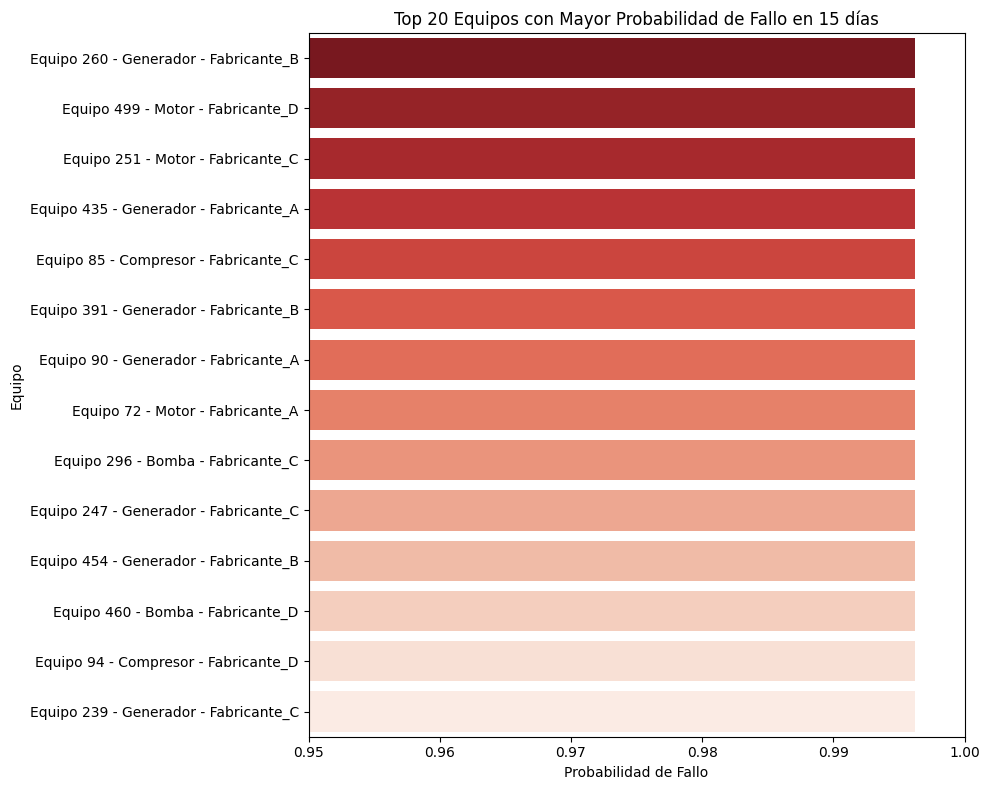

In [103]:
# Seleccionar top 20
top_equipos = df_fallos_final.sort_values(by="prob_fallo_15_dias", ascending=False).head(20)

# Unir con características
top_merged = top_equipos.merge(caracteristicas_df, on="ID_Equipo", how="left")

# Crear etiqueta más informativa
top_merged["Etiqueta_Equipo"] = (
    "Equipo " + top_merged["ID_Equipo"].astype(str)
    + " - " + top_merged["Tipo_Equipo"].astype(str)
    + " - " + top_merged["Fabricante"].astype(str)
)

# Gráfico con etiquetas
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_merged,
    x="prob_fallo_15_dias",
    y="Etiqueta_Equipo",
    hue="Etiqueta_Equipo",     # evitar warning
    palette="Reds_r",
    dodge=False,
    legend=False
)

plt.title("Top 20 Equipos con Mayor Probabilidad de Fallo en 15 días")
plt.xlabel("Probabilidad de Fallo")
plt.ylabel("Equipo")
plt.xlim(0.95, 1.0)
plt.tight_layout()
plt.show()

##### *Mostrar todos los equipos con probabilidad > 0.95 (no solo top 20)*

In [100]:
altos = df_fallos_final[df_fallos_final["prob_fallo_15_dias"] > 0.95].copy()
print("Número de equipos con prob_fallo_15_dias > 0.95:", altos.shape[0])

Número de equipos con prob_fallo_15_dias > 0.95: 2200


In [104]:
# Validación cruzada clásica (entrenamiento)
from sklearn.model_selection import cross_val_score

scores = cross_val_score(modelo_xgb_mejorado, X, y, cv=3, scoring="f1")
print("F1 CV:", scores.mean(), "+/-", scores.std())

# Comparar con resultados de test real
# ¿Hay mucha diferencia entre CV y test final?


F1 CV: 0.995432916748058 +/- 0.0009273566872424222


#### *Este script realiza:*

1. ✅ Entrenamiento sin `ID_Equipo` ni `cluster_equipo`.
2. ✅ Modelo XGBoost regularizado (`reg_alpha`, `reg_lambda`, `max_depth`, etc.).
3. ✅ Evaluación con `cross_val_score`.
4. ✅ Gráfica de curva de aprendizaje para detectar sobreajuste visualmente.

#### Revisar:

- Si el **F1 baja mucho** respecto al modelo original → había fuga de información.
- Si la **curva de validación diverge de la de entrenamiento** → hay overfitting.

F1 CV (sin ID/cluster): 0.9887002635692802 +/- 0.0040769202052554545


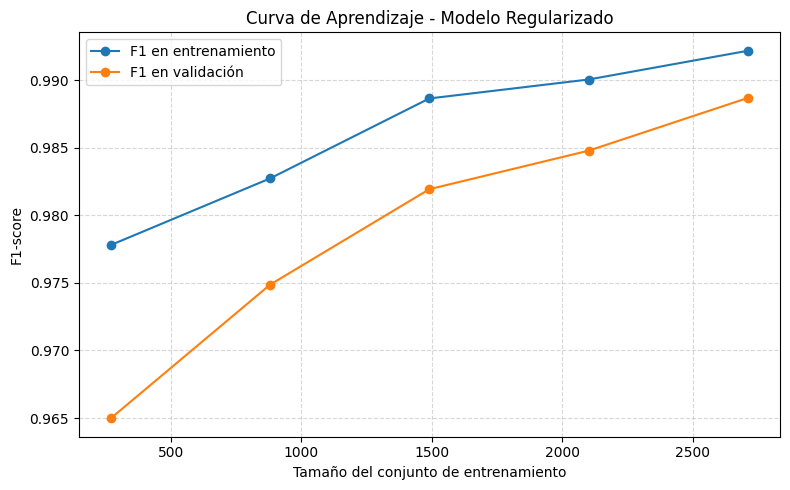

In [105]:
# ✅ Validación para detectar overfitting: sin ID_Equipo ni cluster_equipo
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# 1. Redefinir las columnas sin riesgo de fuga de información
columnas_seguras = [col for col in columnas_clasificacion if col not in ["ID_Equipo", "cluster_equipo"]]
X_seguro = df_clasificacion[columnas_seguras].copy().astype(float)
y_seguro = df_clasificacion["fallo_15_dias"].astype(int)

# 2. Modelo con regularización fuerte para evitar overfitting
modelo_regularizado = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=5.0,
    reg_lambda=10.0,
    eval_metric="logloss",
    random_state=42
)

# 3. Validación cruzada
scores_f1 = cross_val_score(modelo_regularizado, X_seguro, y_seguro, cv=3, scoring="f1")
print("F1 CV (sin ID/cluster):", scores_f1.mean(), "+/-", scores_f1.std())

# 4. Curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(
    modelo_regularizado, X_seguro, y_seguro,
    cv=3, scoring='f1', train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, label="F1 en entrenamiento", marker='o')
plt.plot(train_sizes, test_scores_mean, label="F1 en validación", marker='o')
plt.title("Curva de Aprendizaje - Modelo Regularizado")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### 🔧 Evaluación del Overfitting:
- **F1 en validación (≈ 0.9887)** y entrenamiento (≈ 0.990+) están muy **cerca** ⇒ no hay signos graves de sobreajuste.
- **La distancia entre ambas curvas disminuye** al aumentar el tamaño de entrenamiento ⇒ el modelo **generaliza bien**.
- Quitando `ID_Equipo` y `cluster_equipo`, aún mantienes **alta precisión**, lo que valida que tu modelo no depende de la “identidad” del equipo.

---

### ✅ Conclusiones:

✔️ **No estás sobreajustando**, al menos no de forma crítica.  
✔️ El modelo es **robusto y generaliza bien**.  
✔️ La regularización (α = 5.0, λ = 10.0) y limitación de profundidad (`max_depth=3`) están funcionando.